# ExperimentRobustness

This notebook pits the optical knots against various experimental conditions. Partially copied from the PhaseAnalyzer notebook

In [1]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from pathlib import Path

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from scipy import ndimage
from optical_functions import TotInt, LG, propFF, propTF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric, output_chan_triangle, output_chan_circle, norm_field, build_fresnel_lens_kernels, propagate_fresnel_lens_train, propagate_legacy_fft, complex_field_fidelity, intensity_fidelity, padded_grid_size, center_pad, center_crop, balanced_detector_throughput
from sorter_configuration import parse_optical_train_config
#from run_ga import compute_sorting_performance

import matplotlib.pyplot as plt 

import os

# Physical Constants

nm = 1e-9
um = 1e-6
mm = 1e-3
cm = 1e-2

Load optimized solution

In [2]:
import pickle

index = 19

#experiment_name = "Knot Sorting Bread"
#experiment_name = "Knot Sorting New FF"
#experiment_name = "Knot Sorting Three Knot Fun"
#experiment_name = "Knot Sorting New FF Smaller Alpha"  # use None for configs/ga0.yaml, ga1.yaml, or ga2.yaml
#experiment_name = "Knot Sorting New FF Large Alpha"
#experiment_name = "tref_cinque_fresnel_1plane"
#experiment_name = "Review Response"
experiment_name = "Knot Sorting ga40"

config_path = Path('configs') / (f'ga{index}.yaml' if experiment_name is None else f'{experiment_name}/ga{index}.yaml')
with config_path.open('r', encoding='utf-8') as stream:
    cnfg = yaml.safe_load(stream)

cnfg.setdefault('circle_radius', 1.5)
cnfg.setdefault('alpha', 0.0)

N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
output_chan_width = cnfg['output_chan_width'] * mm # in mm 

num_phase_maps_near = cnfg.get('num_phase_maps_near', 0)
num_phase_maps_far = cnfg.get('num_phase_maps_far', 0)

num_of_phase_maps = cnfg.get('num_phase_planes', num_phase_maps_near + num_phase_maps_far)
optical_train = parse_optical_train_config(cnfg, num_of_phase_maps)
instance_name = cnfg['ga_instance'] # directory name of best phases

# Print the instance name (for reference)

print(instance_name)

# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
shapeParams = cnfg['shapeParams']
knot_mirror = cnfg.get('mirror', [False]*len(knotType))
if isinstance(knot_mirror, bool):
    knot_mirror = [knot_mirror]*len(knotType)
if isKnot and len(knot_mirror) != len(knotType):
    raise ValueError('mirror must contain one boolean per knot input.')
fourier_lens = cnfg.get('fourier_length', 10.0)*cm # legacy propagation only
GFilterStrength=cnfg['gauss_filter_sigma']
channel_seperation = cnfg['channel_sep']
circle_radius = cnfg['circle_radius'] # circle radius is in mm
alpha = cnfg['alpha']

# Define the coordinate space 

la = cnfg.get('wavelength_nm', 780.0)*nm
k=(2*np.pi)/la  # [m^-1] wavenumber    
N = cnfg['dim'] # [Number of points per dimension]
maxx = cnfg.get('pixel_pitch_um', 20.0)*um*N  # Full numerical-window length (m)

# Propagation Distance 
prop_dist = 0

# Let's apply a rotation
rot_phi = eval(cnfg['rot_angle'])

# Space definition 
dx = maxx/N
dy = maxx/N 

# Okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)

h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

# Apply rotation operator on coords 

xx,yy=np.meshgrid(X ,Y)

r, phi= cart2pol(xx, yy)

# What experiment are we going to design

simulateLens = cnfg.get('simulateLens', False)
multiPhase = cnfg.get('multiPhase', False)
multiPhaseLens = cnfg.get('multiPhaseLens', False)

z_o = cnfg.get('z_o', 30.0)*cm
fourier_lens = cnfg.get('fourier_length', 10.0)*cm

''' 
Create the OAM beams that we need to sort 
'''
# Now create a list containing 'oamMode' objects 

list_of_OAMs = []

output_chans = output_chan_circle(X, Y, output_chan_width, maxx, num_of_output_chans, circle_radius=circle_radius, coordinate_mode=optical_train.output_coordinate_mode)

if(isKnot):
    for ii in range(len(knotType)):
        field = setKnotType(
            r, phi, w0, knotType[ii], shapeParams[ii], mirror=knot_mirror[ii]
        )
        prop_field = field
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))
else:
    for ii in range(len(LG_modes)):
        ell, p = LG_modes[ii][0], LG_modes[ii][1]
        field = LG(r, phi, ell, p, w0, h, 0, k)
        prop_field = propTF(field, maxx, la, prop_dist)
        list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))


# Load up phase screens

with open(f"best_phases/{instance_name}.pkl", 'rb') as file:
     phase_out = pickle.load(file)

geometry_path = Path('best_phases/Latest') /  f'{instance_name}_geometry.yaml'
analysis_padding_factor = optical_train.padding_factor
use_saved_geometry = False
if optical_train.model == 'fresnel_lens_train' and geometry_path.exists():
    with geometry_path.open('r', encoding='utf-8') as stream:
        saved_geometry = yaml.safe_load(stream) or {}
    saved_stages = saved_geometry.get('stages', [])
    use_saved_geometry = (
        saved_geometry.get('model') == optical_train.model
        and len(saved_stages) == num_of_phase_maps
    )

if use_saved_geometry:
    analysis_padding_factor = saved_geometry.get('padding_factor', analysis_padding_factor)
    sorter_stages = [
        {'z_to_lens': stage['z_to_lens_cm']*cm,
         'focal_length': stage['focal_length_cm']*cm,
         'z_after_lens': stage['z_after_lens_cm']*cm}
        for stage in saved_stages
    ]
else:
    initial_geometry = optical_train.initial_normalized_geometry if optical_train.num_geometry_genes else None
    sorter_stages = optical_train.decode_geometry(initial_geometry)
    if optical_train.model == 'fresnel_lens_train' and geometry_path.exists():
        print('Ignoring incompatible saved geometry; using optical_train.stages from the YAML.')


phase_maps = np.empty((num_of_phase_maps, N, N), dtype=np.complex128)

# Compute phase screens

for ii in range(num_of_phase_maps):
    phase_maps[ii] = np.exp(1j * phase_out[ii])

analysis_fresnel_kernels = None
if optical_train.model == 'fresnel_lens_train':
    analysis_fresnel_kernels = build_fresnel_lens_kernels(
        (N, N), maxx, la, sorter_stages, r,
        lens_radius=optical_train.lens_aperture_radius,
        padding_factor=analysis_padding_factor,
    )

def propagate_analysis_field(field):
    if optical_train.model != 'fresnel_lens_train':
        raise RuntimeError('propagate_analysis_field is for the physical Fresnel train.')
    return propagate_fresnel_lens_train(
        field, phase_maps, maxx, la, sorter_stages, r,
        lens_radius=optical_train.lens_aperture_radius,
        kernels=analysis_fresnel_kernels,
        padding_factor=analysis_padding_factor,
    )


ga40_tref_cinque_hopf_4plane


In [3]:
# Shared performance helper for the robustness sweeps below.
from optical_functions import shannon_entropy
import time

def compute_sorting_performance(phase_maps, list_of_OAMs, alpha=1.0):

    # Make the dimensionality of our sorting in terms of # of modes
    d = len(list_of_OAMs)
    
    # Now, this is the fitness parameter 

    sorting_performance = np.zeros(d)

    # Also, compute the sorting probability
    sorting_probability = 0

    # Actually, let's introduce the crosstalk matrix 
    crosstalk_matrix = np.zeros((num_of_output_chans, num_of_output_chans))

    # Let's also introduce a new crosstalk matrix to compute the sorting probability
    crosstalk_prob = np.zeros((num_of_output_chans, num_of_output_chans))

    
    # Let's introduce the secret key rate here, actually. 
    secret_key = 0

    # The physical train uses the geometry saved alongside the optimized masks.
    # Keep the historical branch below intact for archived FFT configurations.
    if optical_train.model == 'fresnel_lens_train':
        if d != num_of_output_chans:
            raise ValueError('The input alphabet and detector-channel counts must match.')
        kernels = build_fresnel_lens_kernels(
            (N, N), maxx, la, sorter_stages, r,
            lens_radius=optical_train.lens_aperture_radius,
            padding_factor=analysis_padding_factor,
        )
        efficiency = np.zeros((d, num_of_output_chans), dtype=float)
        for input_index, input_mode in enumerate(list_of_OAMs):
            field = norm_field(input_mode.oamBeam, h)
            input_power = np.sum(np.abs(field)**2)
            final_field = propagate_fresnel_lens_train(
                field, phase_maps, maxx, la, sorter_stages, r,
                lens_radius=optical_train.lens_aperture_radius, kernels=kernels,
                padding_factor=analysis_padding_factor,
            )
            intensity = np.abs(final_field)**2
            for output_index, channel in enumerate(output_chans):
                efficiency[input_index, output_index] = np.sum(intensity*channel)/input_power

        accepted = efficiency.sum(axis=1, keepdims=True)
        assignment = np.divide(efficiency, accepted, out=np.zeros_like(efficiency), where=accepted > 0)
        correct = np.diag(assignment)
        wrong_mean = (assignment.sum(axis=1)-correct)/(d-1)
        channel_contrast = correct-wrong_mean
        overall_sort_perf = alpha*np.min(channel_contrast)+(1-alpha)*np.mean(channel_contrast)
        symbol_error = 1-np.mean(correct)
        secret_key = max(0.0, np.log2(d)-2*shannon_entropy(symbol_error, d))
        return overall_sort_perf, efficiency, secret_key, assignment

    for ii in range(d):

        # Define initial OAM field and correct output channel 

        field = list_of_OAMs[ii].oamBeam 
        
        # Do a proper normalization on the incident field 
        
        field = norm_field(field,h)
        
        # Compute the initial field intensity. This will be important for later
        
        int_knot = np.sum(np.abs(field)**2)
    
        # modulate the field by the first phase map 

        field_mod_1 = field*phase_maps[0]

        # Proceed with our chosen experiment

        # Case 1: We are doing the experiment without any lenses

        if (multiPhase): # Propagate the field by a distance z_o and apply the second phase screen
            field_after = field_mod_1

            for jj in range(1, len(phase_maps)):
                # Propagate the beam by a distance z_o
                field_after = propTF(field_after, maxx, la, z_o)

                # Apply the next phase map (if applicable)
                field_after = field_after*phase_maps[jj]

            # Propagate the beam one final time and observe the final field

            final_field = propTF(field_after, maxx, la, z_o)

        else: # Case 2: We are computing the experiment with the lens 

            if (multiPhaseLens): # Multi-phase experiment with the lens
                field_after = field_mod_1

                for kk in range(1, num_phase_maps_near):
                    # Propagate the beam by a distance z_o 
                    field_after = propTF(field_after, maxx, la, z_o)
                    # Apply the next phase map in the near field (if applicable)
                    field_after = field_after*phase_maps[kk]
                
                # Fourier transform the beam into the far field
                field_lens = fftshift(fft2(field_after))

            elif (simulateLens): # We simulate Faunhofer Diffraction for a more accurate representation of lens propagation
                field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
        
            
            else: # The pure legacy FFT path is handled generically below.
                 field_lens = None
        
            # What happens next depends on the selected legacy propagation mode.
        
            if not multiPhaseLens and not simulateLens:
                final_field = propagate_legacy_fft(field, phase_maps)
            elif (num_phase_maps_far==0):
                # Compute the field intensity 
                final_field = field_lens
        
            else:
                # Modulate the field by the first far field map
                field_mod_2 = field_lens*phase_maps[num_phase_maps_near]
                if (multiPhaseLens):
                    field_after_2 = field_mod_2
                    
                    for ll in range(1+num_phase_maps_near, num_of_phase_maps):
                        # Propagate the beam 
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        # Apply phase to beam 
                        field_after_2 = field_after_2*phase_maps[ll]
            
                 # Apply inverse fourier transform onto beam
                    field_lens_2 = ifft2(ifftshift(field_after_2))

                 # simulate the lens field again. This is the final field. 
                elif (simulateLens):
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else: 
                    field_lens_2 = ifft2(ifftshift(field_mod_2))

                final_field = field_lens_2
        
        # We normalize the final field and compute the intensity 
        
        final_field = norm_field(final_field,h)
        final_field_int = np.abs(final_field)**2
        
        # Define full set of indices, as you would summing through a for loop
        full_index = np.arange(len(output_chans))   
        # Delete ii from the list of full_index, creating a new temporary array
        temp_index = np.delete(full_index, ii)
        # Sum up the "incorrect" channels 
        incorrect_chans = 0
        # New: to construct our crosstalk matrix, let's store the individual intensities
        incorrect_chan_ints = []
        
        for ind in temp_index:
            field_in_pupil = final_field_int*output_chans[ind]
            incorrect_chan_ints.append(np.sum(field_in_pupil)/int_knot)
            incorrect_chans += np.sum(field_in_pupil)/int_knot
            
        # Now, evaluate the sorting performance 
        correct_chans = np.sum(final_field_int*output_chans[ii])/int_knot # normalization is mode-specific
        sorting_performance[ii] = correct_chans - incorrect_chans
        
        # Compute the detector effeciency 
        detect_eff = correct_chans 
        crosstalk_matrix[ii,ii] = detect_eff 

        # Update the sorting probability
        sorting_probability = correct_chans / (correct_chans + incorrect_chans)
        crosstalk_prob[ii, ii] = sorting_probability
        
        # Compute the crosstalk matrix. For more than two modes, we have to be a bit more meticulous with our approach. 
        
        for jj, ind in enumerate(temp_index):
            crosstalk_eff = incorrect_chan_ints[jj]
            crosstalk_matrix[ii, ind] = crosstalk_eff
            crosstalk_prob[ii, ind] = crosstalk_eff
        

    # Compute the "QBER" using the off-diagonals of the crosstalk matrix 
    qber = ((d-1)/d**2)*(crosstalk_matrix.sum() - np.trace(crosstalk_matrix)) # This bounds the qber to 1, in principle

    # Compute the secret key rate
    secret_key = np.log2(d) - 2*shannon_entropy(qber,d)

    # NEW: We keep track of the per-channel sorting performance
    # alpha is a hyperparameter which adjusts the weight between the minimum and the sum of sorting performances across each channel. 
    # At alpha=0.0, we recover the old behavior, while at alpha=1.0, we consider the minimum
    
    overall_sort_perf = alpha*np.min(sorting_performance) - ((1-alpha)/d)*np.sum(sorting_performance)

    return overall_sort_perf, crosstalk_matrix, secret_key, crosstalk_prob

### 2048 x 2048 robustness metrics

All calls to `compute_sorting_performance` below now use the supersampled finite-device propagation tested in `PropTest.ipynb`. Nominal configured modes are rebuilt analytically; perturbed fields are complex-field interpolated to retain the imposed perturbation.

In [4]:
from supersampled_sorting import compute_supersampled_sorting_metrics

robustness_grid_size = 2048
latest_robustness_metrics = None

def _rebuild_nominal_robustness_input(input_index, axis, sample_pitch):
    grid_x, grid_y = np.meshgrid(axis, axis)
    rotation_angle = rot_phi if cnfg.get('fixedRotation', True) else 0.0
    rotated_x = np.cos(rotation_angle)*grid_x - np.sin(rotation_angle)*grid_y
    rotated_y = np.sin(rotation_angle)*grid_x + np.cos(rotation_angle)*grid_y
    radius, azimuth = cart2pol(rotated_x, rotated_y)
    if isKnot:
        return setKnotType(
            radius, azimuth, w0, knotType[input_index],
            shapeParams[input_index], mirror=knot_mirror[input_index],
        )
    ell, radial_index = LG_modes[input_index]
    return LG(
        radius, azimuth, ell, radial_index, w0, sample_pitch, 0, k
    )

def compute_sorting_performance(
    phase_maps, modes, alpha=None, evaluation_grid_size=robustness_grid_size
):
    global latest_robustness_metrics
    if alpha is None:
        alpha = float(cnfg.get('alpha', 1.0))
    exact_nominal_sampler = (
        _rebuild_nominal_robustness_input
        if modes is list_of_OAMs else None
    )
    latest_robustness_metrics = compute_supersampled_sorting_metrics(
        phase_maps,
        [mode.oamBeam for mode in modes],
        output_chans,
        h,
        evaluation_grid_size=evaluation_grid_size,
        alpha=alpha,
        throughput_metric=cnfg.get('throughput_metric', 'geometric_mean'),
        optical_model=optical_train.model,
        field_sampler=exact_nominal_sampler,
        wavelength=la,
        stages=sorter_stages,
        lens_radius=optical_train.lens_aperture_radius,
        config=cnfg,
    )
    return (
        latest_robustness_metrics['sorting_performance'],
        latest_robustness_metrics['efficiency_matrix'],
        latest_robustness_metrics['secret_key'],
        latest_robustness_metrics['coincidence_probabilities'],
    )

# Test 1:  Effects of z- propagation on sorter performance

What happens when we propagate the input knotted field longitudinally over a range z? 

In [5]:
# Pad the free-space input propagation while preserving the native dx.
# The propagated result is cropped back to N x N before entering the sorter,
# whose phase plates and detector channels are defined on the native grid.
z_propagation_padding_factor = 3.0
z_propagation_grid_size = padded_grid_size(
    N, z_propagation_padding_factor
)
z_propagation_window_width = z_propagation_grid_size*h

def propagate_input_offset(field, z_offset, return_padded=False):
    padded_field = center_pad(
        field, (z_propagation_grid_size, z_propagation_grid_size),
        fill_value=0,
    )
    padded_output = propTF(
        padded_field, z_propagation_window_width, la, z_offset
    )
    native_output = center_crop(padded_output, (N, N))
    if return_padded:
        return native_output, padded_output
    return native_output

print(
    f'z-offset propagation grid: {z_propagation_grid_size} x '
    f'{z_propagation_grid_size}, '
    f'width={z_propagation_window_width/mm:.3f} mm, '
    f'dx={h/um:.1f} um'
)

def prop_knots(z_offset):
    """Introduce a longitudinal offset using padded propagation."""

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(
                r, phi, w0, knotType[ii], shapeParams[ii], mirror=knot_mirror[ii]
            )
            prop_field = propagate_input_offset(field, z_offset)
            list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            field = LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k)
            prop_field = propagate_input_offset(field, z_offset)
            list_of_OAMs.append(oamModes(prop_field, output_chans[ii]))
    
    return list_of_OAMs


z-offset propagation grid: 384 x 384, width=3.072 mm, dx=8.0 um


In [6]:
def full_fitness_from_efficiency(efficiency_matrix):
    """Reproduce run_ga.py's full objective from detector efficiencies."""
    efficiency_matrix = np.asarray(efficiency_matrix, dtype=float)
    if (
        efficiency_matrix.ndim != 2
        or efficiency_matrix.shape[0] != efficiency_matrix.shape[1]
    ):
        raise ValueError('The full metric requires a square efficiency matrix.')

    d = efficiency_matrix.shape[0]
    accepted_power = efficiency_matrix.sum(axis=1, keepdims=True)
    assignment_matrix = np.divide(
        efficiency_matrix, accepted_power,
        out=np.zeros_like(efficiency_matrix), where=accepted_power > 0,
    )

    correct = np.diag(assignment_matrix)
    incorrect_mean = (assignment_matrix.sum(axis=1)-correct)/(d-1)
    channel_contrast = correct-incorrect_mean
    metric_alpha = float(cnfg.get('alpha', 1.0))
    balanced_contrast = (
        metric_alpha*np.min(channel_contrast)
        +(1-metric_alpha)*np.mean(channel_contrast)
    )

    symbol_error = 1-np.mean(correct)
    secret_key = max(0.0, np.log2(d)-2*shannon_entropy(symbol_error, d))
    throughput_metric = str(cnfg.get('throughput_metric', 'geometric_mean'))
    throughput, accepted_efficiencies = balanced_detector_throughput(
        efficiency_matrix, method=throughput_metric
    )
    metric_gamma = float(cnfg.get('gamma', 1.0))
    distinguishability = abs(np.linalg.det(assignment_matrix))**metric_gamma
    throughput_exponent = float(cnfg.get('throughput_exponent', 1.0))
    throughput_factor = (
        1.0 if throughput_exponent == 0.0
        else throughput**throughput_exponent
    )
    full_fitness = float(np.real(
        balanced_contrast*secret_key*distinguishability*throughput_factor
    ))
    components = {
        'balanced_contrast': float(balanced_contrast),
        'secret_key': float(secret_key),
        'distinguishability': float(distinguishability),
        'throughput': float(throughput),
        'accepted_efficiencies': accepted_efficiencies,
        'assignment_matrix': assignment_matrix,
    }
    return full_fitness, components


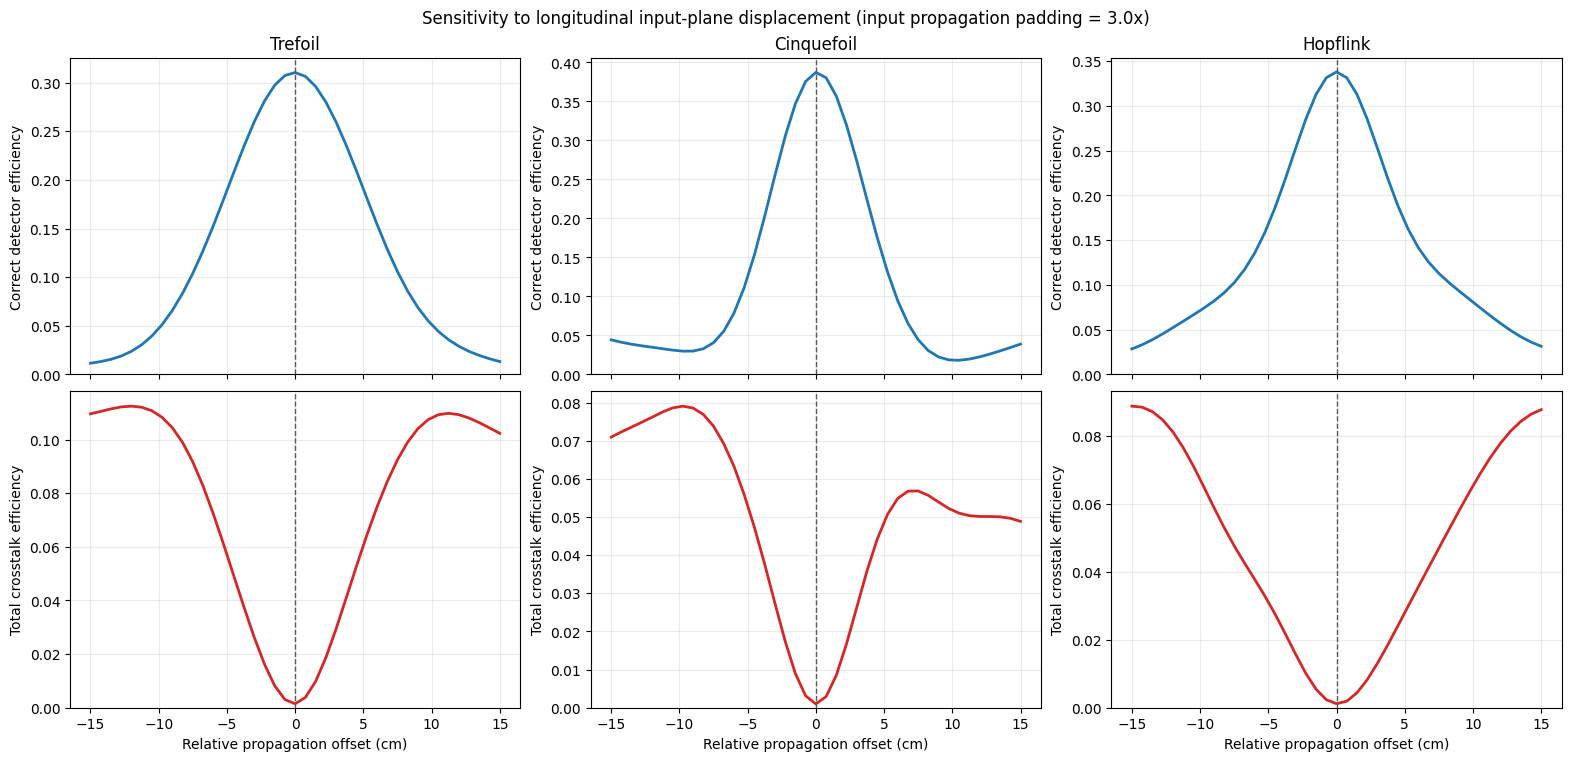

Trefoil: z=0 mm, efficiency=0.310367, crosstalk=0.00147973
Cinquefoil: z=0 mm, efficiency=0.387264, crosstalk=0.000993612
Hopflink: z=0 mm, efficiency=0.33804, crosstalk=0.00117431


In [7]:
# Relative longitudinal displacement of each input from the nominal first phase plane.
z_offsets_mm = np.linspace(-15, 15, 41)
z_offsets = z_offsets_mm*cm
mode_labels = knotType if isKnot else [f'LG({ell}, {p})' for ell, p in LG_modes]

offset_efficiency = np.zeros((len(mode_labels), len(z_offsets)))
offset_crosstalk = np.zeros_like(offset_efficiency)

def propagate_offset_input(field):
    field = norm_field(field, h)
    input_power = np.sum(np.abs(field)**2)
    if optical_train.model == 'fresnel_lens_train':
        output = propagate_analysis_field(field)
    else:
        output = norm_field(propagate_legacy_fft(field, phase_maps), h)
    detector_powers = np.asarray([
        np.real(np.sum(np.abs(output)**2*channel)/input_power)
        for channel in output_chans
    ], dtype=float)
    return detector_powers

for offset_index, z_offset in enumerate(z_offsets):
    displaced_modes = prop_knots(z_offset)
    for mode_index, displaced_mode in enumerate(displaced_modes):
        detector_powers = propagate_offset_input(displaced_mode.oamBeam)
        offset_efficiency[mode_index, offset_index] = detector_powers[mode_index]
        offset_crosstalk[mode_index, offset_index] = (
            detector_powers.sum()-detector_powers[mode_index]
        )

fig, axes = plt.subplots(
    2, len(mode_labels),
    figsize=(5.2*len(mode_labels), 7.5),
    sharex=True, squeeze=False, constrained_layout=True,
)
for mode_index, label in enumerate(mode_labels):
    axes[0, mode_index].plot(
        z_offsets_mm, offset_efficiency[mode_index],
        color='tab:blue', linewidth=2,
    )
    axes[1, mode_index].plot(
        z_offsets_mm, offset_crosstalk[mode_index],
        color='tab:red', linewidth=2,
    )
    axes[0, mode_index].set_title(label)
    axes[0, mode_index].set_ylabel('Correct detector efficiency')
    axes[1, mode_index].set_ylabel('Total crosstalk efficiency')
    axes[1, mode_index].set_xlabel('Relative propagation offset (cm)')
    for axis in axes[:, mode_index]:
        axis.axvline(0.0, color='0.35', linestyle='--', linewidth=1)
        axis.grid(alpha=0.25)
        axis.set_ylim(bottom=0)

fig.suptitle(
    'Sensitivity to longitudinal input-plane displacement '
    f'(input propagation padding = {z_propagation_grid_size/N:.1f}x)'
)
plt.show()

zero_index = int(np.argmin(np.abs(z_offsets_mm)))
for mode_index, label in enumerate(mode_labels):
    print(
        f'{label}: z=0 mm, efficiency={offset_efficiency[mode_index, zero_index]:.6g}, '
        f'crosstalk={offset_crosstalk[mode_index, zero_index]:.6g}'
    )


Saved z-offset movie to plots\ga40_tref_cinque_hopf_4plane_z_offset_input_output.gif


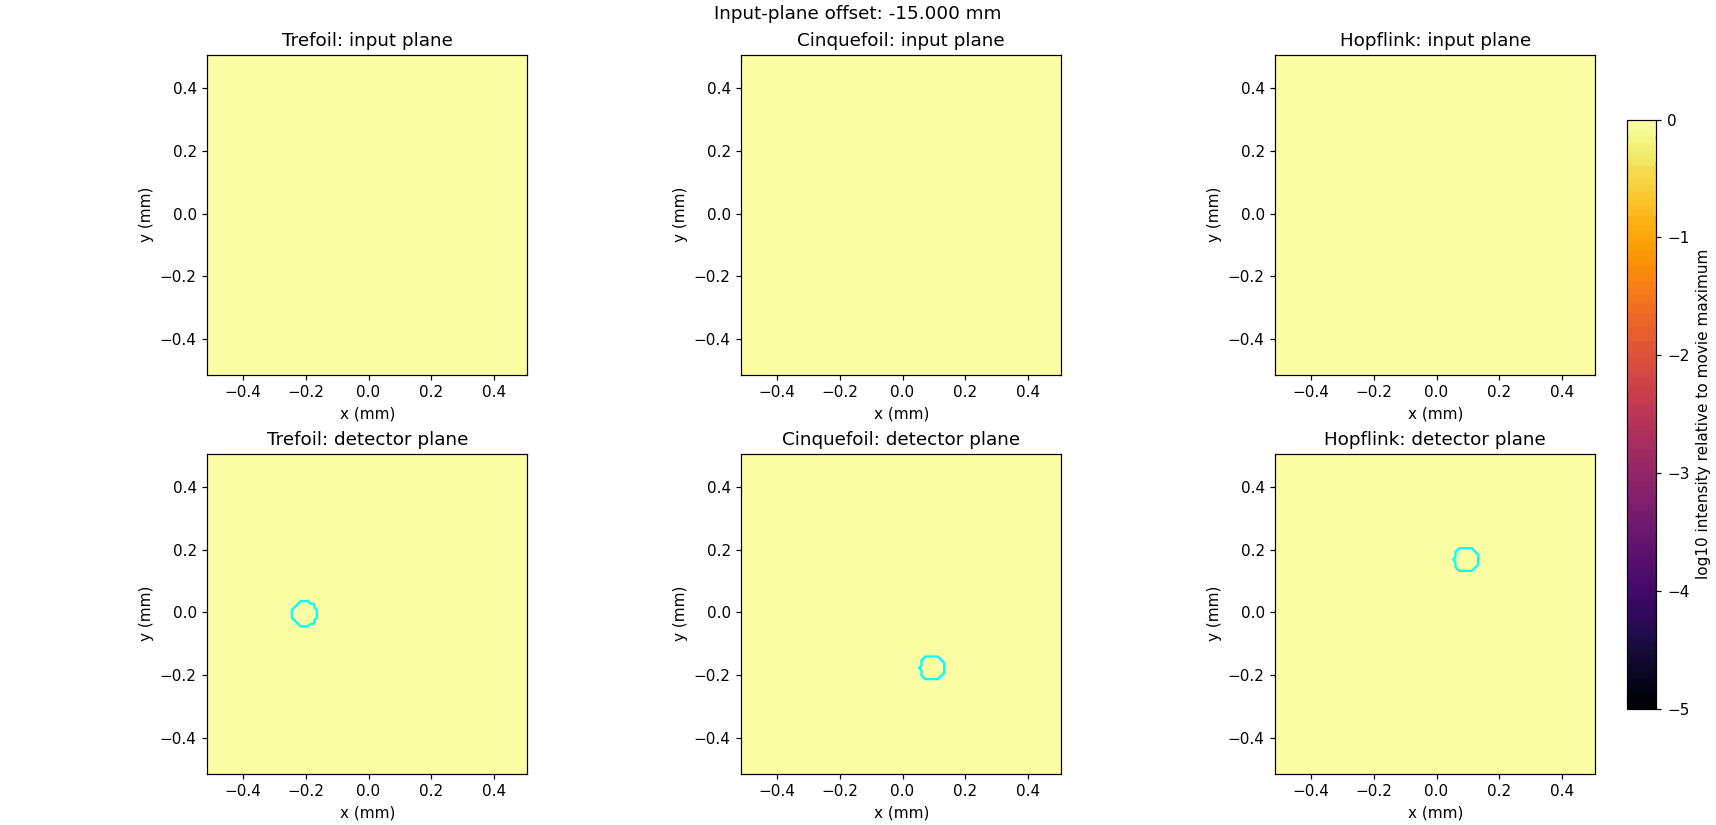

In [8]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPythonImage, display

# Precompute the input and detector-plane intensities on the same offset grid
# used above. Fixed scales across all frames make genuine power redistribution
# visible instead of renormalizing it away frame by frame.
movie_input_intensity = np.zeros(
    (len(z_offsets), len(mode_labels), N, N), dtype=float
)
movie_output_intensity = np.zeros_like(movie_input_intensity)

def sorter_output_field(field):
    field = norm_field(field, h)
    if optical_train.model == 'fresnel_lens_train':
        return field, propagate_analysis_field(field)
    return field, norm_field(propagate_legacy_fft(field, phase_maps), h)

for offset_index, z_offset in enumerate(z_offsets):
    displaced_modes = prop_knots(z_offset)
    for mode_index, displaced_mode in enumerate(displaced_modes):
        input_field, output_field = sorter_output_field(displaced_mode.oamBeam)
        movie_input_intensity[offset_index, mode_index] = np.abs(input_field)**2
        movie_output_intensity[offset_index, mode_index] = np.abs(output_field)**2

input_maximum = movie_input_intensity.max(axis=(0, 2, 3))
output_maximum = movie_output_intensity.max(axis=(0, 2, 3))
movie_dynamic_range_decades = 5
movie_floor = 10.0**(-movie_dynamic_range_decades)

def log_movie_frame(intensity, maximum):
    relative = intensity/maximum if maximum > 0 else intensity
    return np.maximum(relative, movie_floor)

movie_extent_mm = (X[0]/mm, X[-1]/mm, Y[0]/mm, Y[-1]/mm)
movie_figure, movie_axes = plt.subplots(
    2, len(mode_labels), figsize=(5.2*len(mode_labels), 7.5),
    squeeze=False, constrained_layout=True,
)
movie_images = []
for mode_index, label in enumerate(mode_labels):
    input_image = movie_axes[0, mode_index].imshow(
        log_movie_frame(movie_input_intensity[0, mode_index], input_maximum[mode_index]),
        origin='lower', cmap='inferno', vmin=-movie_dynamic_range_decades, vmax=0,
        extent=movie_extent_mm,
    )
    output_image = movie_axes[1, mode_index].imshow(
        log_movie_frame(movie_output_intensity[0, mode_index], output_maximum[mode_index]),
        origin='lower', cmap='inferno', vmin=-movie_dynamic_range_decades, vmax=0,
        extent=movie_extent_mm,
    )
    movie_images.append((input_image, output_image))
    movie_axes[0, mode_index].set_title(f'{label}: input plane')
    movie_axes[1, mode_index].set_title(f'{label}: detector plane')
    movie_axes[1, mode_index].contour(
        np.real(output_chans[mode_index]), levels=[0.5], colors='cyan',
        linewidths=1.5, extent=movie_extent_mm,
    )
    for axis in movie_axes[:, mode_index]:
        axis.set_xlabel('x (mm)')
        axis.set_ylabel('y (mm)')

movie_title = movie_figure.suptitle('')
movie_colorbar = movie_figure.colorbar(
    movie_images[0][0], ax=movie_axes, shrink=0.82, pad=0.02,
)
movie_colorbar.set_label('log10 intensity relative to movie maximum')

def update_z_offset_movie(frame_index):
    artists = []
    for mode_index, (input_image, output_image) in enumerate(movie_images):
        input_image.set_data(log_movie_frame(
            movie_input_intensity[frame_index, mode_index], input_maximum[mode_index]
        ))
        output_image.set_data(log_movie_frame(
            movie_output_intensity[frame_index, mode_index], output_maximum[mode_index]
        ))
        artists.extend((input_image, output_image))
    movie_title.set_text(
        f'Input-plane offset: {z_offsets_mm[frame_index]:+.3f} mm'
    )
    artists.append(movie_title)
    return artists

z_offset_animation = FuncAnimation(
    movie_figure, update_z_offset_movie, frames=len(z_offsets),
    interval=125, blit=False, repeat=True,
)
movie_path = Path('plots')/f'{instance_name}_z_offset_input_output.gif'
movie_path.parent.mkdir(parents=True, exist_ok=True)
z_offset_animation.save(movie_path, writer=PillowWriter(fps=8), dpi=110)
plt.close(movie_figure)
print(f'Saved z-offset movie to {movie_path}')
display(IPythonImage(filename=str(movie_path)))


# Test 2: Effects of Chirality

What happens when we sort as input a mirror image? This can be realized by flipping the sign of the OAM components of the knot.

In [16]:
def mirror_knots():
    """Flip every input's azimuthal/OAM charge at the nominal input plane."""
    mirrored_modes = []

    if isKnot:
        for ii in range(len(knotType)):
            field = setKnotType(
                r, phi, w0, knotType[ii], shapeParams[ii],
                mirror=not knot_mirror[ii],
            )
            mirrored_modes.append(oamModes(field, output_chans[ii]))
    else:
        for ii, (ell, radial_index) in enumerate(LG_modes):
            field = LG(r, phi, -ell, radial_index, w0, h, 0, k)
            mirrored_modes.append(oamModes(field, output_chans[ii]))

    return mirrored_modes


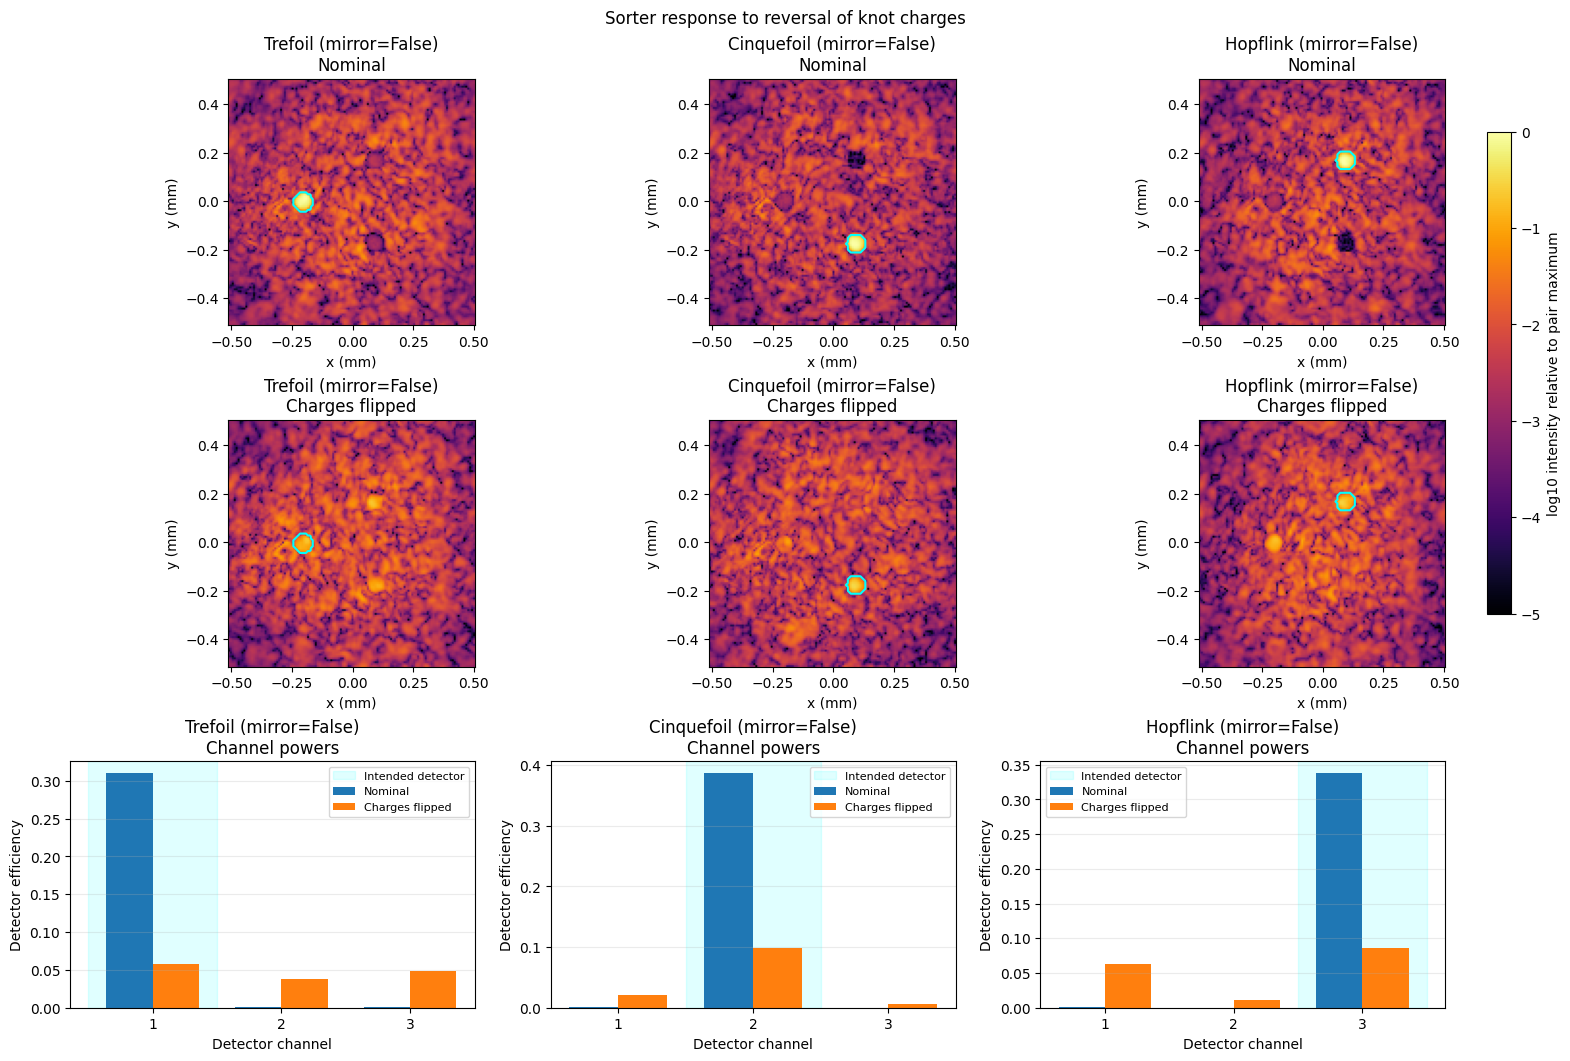

Saved charge-flip comparison to plots\ga40_tref_cinque_hopf_4plane_charge_flip_sorting.png
Nominal efficiency matrix (rows: inputs; columns: detectors):
[[3.10366812e-01 5.70210954e-04 9.09517683e-04]
 [9.20470191e-04 3.87263519e-01 7.31418146e-05]
 [1.11765404e-03 5.66590182e-05 3.38039605e-01]]
Charge-flipped efficiency matrix:
[[0.05838491 0.03794567 0.04853686]
 [0.02065236 0.09821832 0.00540983]
 [0.06340307 0.01040755 0.08558391]]


In [17]:
# Compare the trained sorter's response to each nominal input and to the
# same input with all azimuthal/OAM charges reversed.
nominal_modes = list_of_OAMs
charge_flipped_modes = mirror_knots()
chirality_mode_labels = (
    [f'{name} (mirror={knot_mirror[ii]})' for ii, name in enumerate(knotType)]
    if isKnot else [f'LG({ell}, {p})' for ell, p in LG_modes]
)
chirality_variants = ('Nominal', 'Charges flipped')
chirality_intensity = np.zeros(
    (2, len(chirality_mode_labels), N, N), dtype=float
)
chirality_efficiency = np.zeros(
    (2, len(chirality_mode_labels), num_of_output_chans), dtype=float
)

def propagate_chirality_input(field):
    normalized_input = norm_field(field, h)
    input_power = np.sum(np.abs(normalized_input)**2)
    if optical_train.model == 'fresnel_lens_train':
        output = propagate_analysis_field(normalized_input)
    else:
        output = norm_field(
            propagate_legacy_fft(normalized_input, phase_maps), h
        )
    detector_powers = np.asarray([
        np.real(np.sum(np.abs(output)**2*channel)/input_power)
        for channel in output_chans
    ])
    return output, detector_powers

for variant_index, modes in enumerate((nominal_modes, charge_flipped_modes)):
    for mode_index, mode in enumerate(modes):
        output, detector_powers = propagate_chirality_input(mode.oamBeam)
        chirality_intensity[variant_index, mode_index] = np.abs(output)**2
        chirality_efficiency[variant_index, mode_index] = detector_powers

chirality_extent_mm = (X[0]/mm, X[-1]/mm, Y[0]/mm, Y[-1]/mm)
chirality_dynamic_range_decades = 5
chirality_floor = 10.0**(-chirality_dynamic_range_decades)
chirality_figure, chirality_axes = plt.subplots(
    3, len(chirality_mode_labels),
    figsize=(5.2*len(chirality_mode_labels), 10.5),
    squeeze=False, constrained_layout=True,
)
chirality_images = []
detector_indices = np.arange(num_of_output_chans)

for mode_index, label in enumerate(chirality_mode_labels):
    pair_maximum = chirality_intensity[:, mode_index].max()
    for variant_index, variant_label in enumerate(chirality_variants):
        relative = chirality_intensity[variant_index, mode_index]/pair_maximum
        log_intensity = np.log10(np.maximum(relative, chirality_floor))
        image = chirality_axes[variant_index, mode_index].imshow(
            log_intensity, origin='lower', cmap='inferno',
            vmin=-chirality_dynamic_range_decades, vmax=0,
            extent=chirality_extent_mm,
        )
        chirality_images.append(image)
        chirality_axes[variant_index, mode_index].contour(
            np.real(output_chans[mode_index]), levels=[0.5], colors='cyan',
            linewidths=1.5, extent=chirality_extent_mm,
        )
        chirality_axes[variant_index, mode_index].set_title(
            f'{label}\n{variant_label}'
        )
        chirality_axes[variant_index, mode_index].set_xlabel('x (mm)')
        chirality_axes[variant_index, mode_index].set_ylabel('y (mm)')

    bar_axis = chirality_axes[2, mode_index]
    bar_axis.axvspan(
        mode_index-0.5, mode_index+0.5, color='cyan', alpha=0.12,
        label='Intended detector',
    )
    bar_axis.bar(
        detector_indices-0.18, chirality_efficiency[0, mode_index],
        width=0.36, label='Nominal', color='tab:blue',
    )
    bar_axis.bar(
        detector_indices+0.18, chirality_efficiency[1, mode_index],
        width=0.36, label='Charges flipped', color='tab:orange',
    )
    bar_axis.set_xticks(detector_indices, detector_indices+1)
    bar_axis.set_xlabel('Detector channel')
    bar_axis.set_ylabel('Detector efficiency')
    bar_axis.set_title(f'{label}\nChannel powers')
    bar_axis.set_ylim(bottom=0)
    bar_axis.grid(axis='y', alpha=0.25)
    bar_axis.legend(fontsize=8)

chirality_colorbar = chirality_figure.colorbar(
    chirality_images[0], ax=chirality_axes[:2, :], shrink=0.82, pad=0.02,
)
chirality_colorbar.set_label('log10 intensity relative to pair maximum')
chirality_figure.suptitle('Sorter response to reversal of knot charges')
chirality_plot_path = (
    Path('plots')/f'{instance_name}_charge_flip_sorting.png'
)
chirality_plot_path.parent.mkdir(parents=True, exist_ok=True)
chirality_figure.savefig(chirality_plot_path, dpi=150)
plt.show()
print(f'Saved charge-flip comparison to {chirality_plot_path}')

print('Nominal efficiency matrix (rows: inputs; columns: detectors):')
print(chirality_efficiency[0])
print('Charge-flipped efficiency matrix:')
print(chirality_efficiency[1])


# Test 3: a- and b- parameter sweep

What happens when we sweep through the a- and b- parameters of the input knotted beam? 

In [33]:
def mold_knots(a_offset, b_offset):

    """Rebuild each knot after additive changes to its a and b parameters."""

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            shapeParams_a, shapeParams_b, shapeParams_s = shapeParams[ii]
            # Introduce the offset for a, b, and s parameters (when applicable)
            shapeParams_a += a_offset
            shapeParams_b += b_offset
            # Put everything back together
            shapes = [shapeParams_a, shapeParams_b, shapeParams_s]
            field = setKnotType(
                r, phi, w0, knotType[ii], shapes, mirror=knot_mirror[ii]
            )
            list_of_OAMs.append(oamModes(field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            field = LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k)
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))
    
    return list_of_OAMs


# Generate the offset in the a- and b- parameterization

a_offset = np.linspace(-0.25, 0.25, 10)
b_offset = np.linspace(-0.25, 0.25, 10)


Completed 1/10 a-offset rows
Completed 2/10 a-offset rows
Completed 3/10 a-offset rows
Completed 4/10 a-offset rows
Completed 5/10 a-offset rows
Completed 6/10 a-offset rows
Completed 7/10 a-offset rows
Completed 8/10 a-offset rows
Completed 9/10 a-offset rows
Completed 10/10 a-offset rows


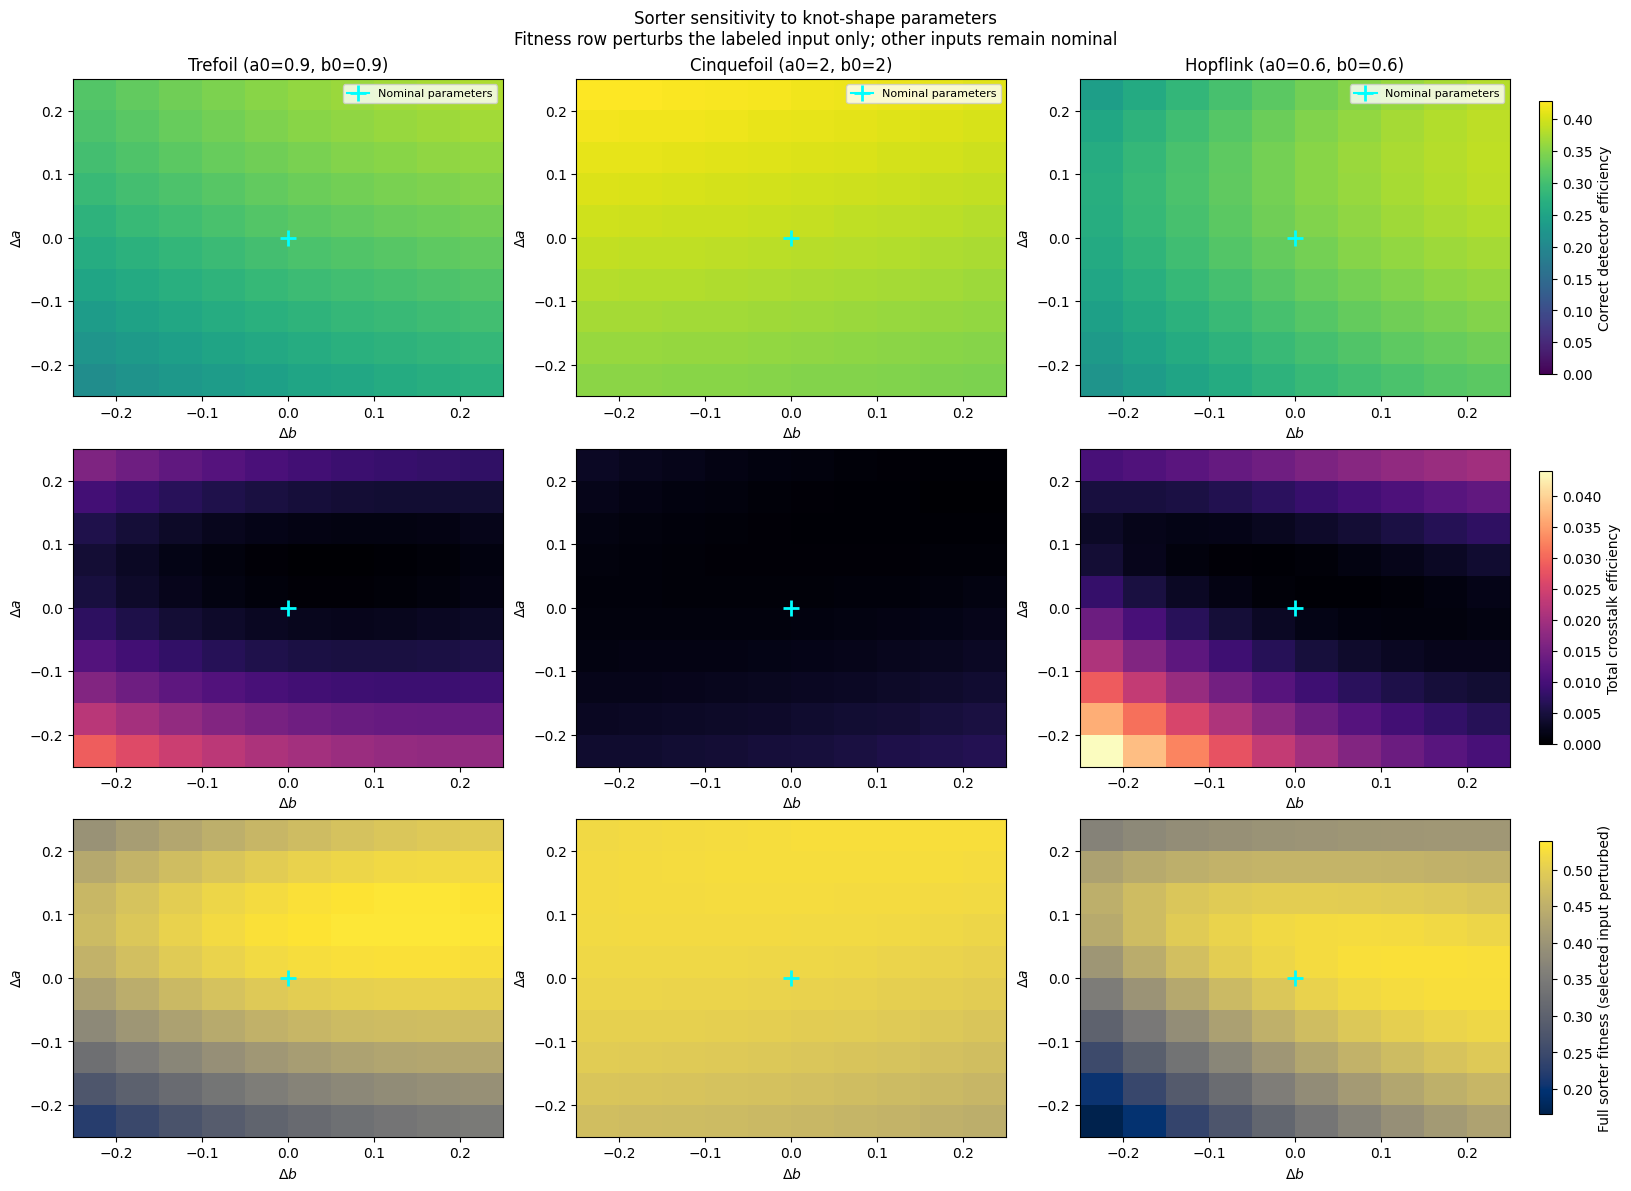

Saved a/b parameter sweep to plots\ga40_tref_cinque_hopf_4plane_ab_parameter_sweep.png
Exact nominal full sorter fitness=0.511428
Trefoil (a0=0.9, b0=0.9): nearest-to-nominal efficiency=0.300267, crosstalk=0.00279853, full fitness=0.49208
Cinquefoil (a0=2, b0=2): nearest-to-nominal efficiency=0.384058, crosstalk=0.00119678, full fitness=0.508707
Hopflink (a0=0.6, b0=0.6): nearest-to-nominal efficiency=0.327304, crosstalk=0.00293917, full fitness=0.49035


In [34]:
# Evaluate sorting performance throughout the additive (delta-a, delta-b) grid.
if not isKnot:
    raise RuntimeError('The a/b parameter sweep is defined only for knot inputs.')

ab_mode_labels = [
    f'{name} (a0={params[0]:g}, b0={params[1]:g})'
    for name, params in zip(knotType, shapeParams)
]
ab_correct_efficiency = np.zeros(
    (len(knotType), len(a_offset), len(b_offset)), dtype=float
)
ab_crosstalk_efficiency = np.zeros_like(ab_correct_efficiency)
ab_full_fitness = np.zeros_like(ab_correct_efficiency)

def propagate_molded_input(field):
    normalized_input = norm_field(field, h)
    input_power = np.sum(np.abs(normalized_input)**2)
    if optical_train.model == 'fresnel_lens_train':
        output = propagate_analysis_field(normalized_input)
    else:
        output = norm_field(
            propagate_legacy_fft(normalized_input, phase_maps), h
        )
    return np.asarray([
        np.real(np.sum(np.abs(output)**2*channel)/input_power)
        for channel in output_chans
    ])

# The full objective is a sorter-level metric.  For each column below,
# perturb only that input and keep every other input at its nominal field.
ab_nominal_efficiency_matrix = np.asarray([
    propagate_molded_input(mode.oamBeam) for mode in list_of_OAMs
])
ab_nominal_full_fitness, _ = full_fitness_from_efficiency(
    ab_nominal_efficiency_matrix
)

progress_interval = max(1, len(a_offset)//10)
for a_index, delta_a in enumerate(a_offset):
    for b_index, delta_b in enumerate(b_offset):
        molded_modes = mold_knots(delta_a, delta_b)
        for mode_index, molded_mode in enumerate(molded_modes):
            detector_powers = propagate_molded_input(molded_mode.oamBeam)
            ab_correct_efficiency[mode_index, a_index, b_index] = (
                detector_powers[mode_index]
            )
            ab_crosstalk_efficiency[mode_index, a_index, b_index] = (
                detector_powers.sum()-detector_powers[mode_index]
            )
            perturbed_efficiency_matrix = (
                ab_nominal_efficiency_matrix.copy()
            )
            perturbed_efficiency_matrix[mode_index] = detector_powers
            ab_full_fitness[mode_index, a_index, b_index], _ = (
                full_fitness_from_efficiency(perturbed_efficiency_matrix)
            )
    if (a_index+1) % progress_interval == 0 or a_index == len(a_offset)-1:
        print(f'Completed {a_index+1}/{len(a_offset)} a-offset rows')

ab_extent = (b_offset[0], b_offset[-1], a_offset[0], a_offset[-1])
ab_figure, ab_axes = plt.subplots(
    3, len(ab_mode_labels),
    figsize=(5.4*len(ab_mode_labels), 11.8),
    squeeze=False, constrained_layout=True,
)
correct_scale_max = max(float(ab_correct_efficiency.max()), np.finfo(float).eps)
crosstalk_scale_max = max(float(ab_crosstalk_efficiency.max()), np.finfo(float).eps)
fitness_scale_min = float(ab_full_fitness.min())
fitness_scale_max = float(ab_full_fitness.max())
if np.isclose(fitness_scale_min, fitness_scale_max):
    fitness_scale_padding = max(
        abs(fitness_scale_min)*1e-6, np.finfo(float).eps
    )
    fitness_scale_min -= fitness_scale_padding
    fitness_scale_max += fitness_scale_padding
correct_images = []
crosstalk_images = []
fitness_images = []

for mode_index, label in enumerate(ab_mode_labels):
    correct_image = ab_axes[0, mode_index].imshow(
        ab_correct_efficiency[mode_index], origin='lower', aspect='auto',
        extent=ab_extent, cmap='viridis', vmin=0, vmax=correct_scale_max,
    )
    crosstalk_image = ab_axes[1, mode_index].imshow(
        ab_crosstalk_efficiency[mode_index], origin='lower', aspect='auto',
        extent=ab_extent, cmap='magma', vmin=0, vmax=crosstalk_scale_max,
    )
    fitness_image = ab_axes[2, mode_index].imshow(
        ab_full_fitness[mode_index], origin='lower', aspect='auto',
        extent=ab_extent, cmap='cividis',
        vmin=fitness_scale_min, vmax=fitness_scale_max,
    )
    correct_images.append(correct_image)
    crosstalk_images.append(crosstalk_image)
    fitness_images.append(fitness_image)
    ab_axes[0, mode_index].set_title(label)
    for axis in ab_axes[:, mode_index]:
        axis.plot(0, 0, marker='+', color='cyan', markersize=12,
                  markeredgewidth=2, label='Nominal parameters')
        axis.set_xlabel(r'$\Delta b$')
        axis.set_ylabel(r'$\Delta a$')
    ab_axes[0, mode_index].legend(loc='upper right', fontsize=8)

correct_colorbar = ab_figure.colorbar(
    correct_images[0], ax=ab_axes[0, :], shrink=0.86, pad=0.02,
)
correct_colorbar.set_label('Correct detector efficiency')
crosstalk_colorbar = ab_figure.colorbar(
    crosstalk_images[0], ax=ab_axes[1, :], shrink=0.86, pad=0.02,
)
crosstalk_colorbar.set_label('Total crosstalk efficiency')
fitness_colorbar = ab_figure.colorbar(
    fitness_images[0], ax=ab_axes[2, :], shrink=0.86, pad=0.02,
)
fitness_colorbar.set_label(
    'Full sorter fitness (selected input perturbed)'
)
ab_figure.suptitle(
    'Sorter sensitivity to knot-shape parameters'
    '\nFitness row perturbs the labeled input only; other inputs remain nominal'
)
ab_plot_path = Path('plots')/f'{instance_name}_ab_parameter_sweep.png'
ab_plot_path.parent.mkdir(parents=True, exist_ok=True)
ab_figure.savefig(ab_plot_path, dpi=150)
plt.show()

zero_a_index = int(np.argmin(np.abs(a_offset)))
zero_b_index = int(np.argmin(np.abs(b_offset)))
print(f'Saved a/b parameter sweep to {ab_plot_path}')
print(f'Exact nominal full sorter fitness={ab_nominal_full_fitness:.6g}')
for mode_index, label in enumerate(ab_mode_labels):
    print(
        f'{label}: nearest-to-nominal efficiency='
        f'{ab_correct_efficiency[mode_index, zero_a_index, zero_b_index]:.6g}, '
        f'crosstalk='
        f'{ab_crosstalk_efficiency[mode_index, zero_a_index, zero_b_index]:.6g}, '
        f'full fitness='
        f'{ab_full_fitness[mode_index, zero_a_index, zero_b_index]:.6g}'
    )


# Test 4: Effect of Rotation on Hologram 

We can optionally apply rotations/translations onto the knotted field

In [20]:
# Rotates the incident knot by rot_phi

# rotate_mode: if None, rotate all modes; otherwise only rotate the specified mode index

def create_rotated_knots(rot_phi, rotate_mode=None):
    
    # Apply rotation operator on coords. Update: The rotation should be 
    # X_rot = np.cos(rot_phi)*X - np.sin(rot_phi)*Y
    # Y_rot = np.sin(rot_phi)*X + np.cos(rot_phi)*Y

    xx,yy=np.meshgrid(X ,Y)
    
    xx_rot = np.cos(rot_phi)*xx - np.sin(rot_phi)*yy
    yy_rot = np.sin(rot_phi)*xx + np.cos(rot_phi)*yy

    r_rot, phi_rot = cart2pol(xx_rot,yy_rot)

    ''' 
    Create the OAM beams that we need to sort 
    '''
    # Now create a list containing 'oamMode' objects 

    list_of_OAMs = []

    if(isKnot):
        for ii in range(len(knotType)):
            # Rotate only the selected mode (if rotate_mode is specified)
            if (rotate_mode is None) or (ii == rotate_mode):
                field_r = setKnotType(r_rot, phi_rot, w0, knotType[ii], shapeParams[ii])
            else:
                field_r = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            list_of_OAMs.append(oamModes(field_r, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            if (rotate_mode is None) or (ii == rotate_mode):
                field_r = LG(r_rot, phi_rot, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k)
            else:
                field_r = LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k)
            list_of_OAMs.append(oamModes(field_r, output_chans[ii]))
    
    return list_of_OAMs


Iterating over the range of different angles, compute rotational effects. 

For three modes, remember that we have to account for two kinds of crosstalk.

In [ ]:
rotate_angles = np.linspace(0, 2*np.pi, num=50)
mean_effs = []
mean_crosses_1 = []
mean_crosses_2 = []

mode=0

for angle in rotate_angles: 
    # Generate the rotated fields (rotate only the selected mode)
    list_of_rotated_OAMs = create_rotated_knots(angle, rotate_mode=mode)
    # Compute the crosstalk matrix 
    simulateLens = False
    sorting_performance, crosstalk_matrix, _, _= compute_sorting_performance(phase_maps, list_of_rotated_OAMs)

    mean_eff = crosstalk_matrix[mode,mode]
    mean_cross_1 = crosstalk_matrix[mode,(mode+1)%3]
    mean_cross_2 = crosstalk_matrix[mode,(mode+2)%3]
    
    mean_effs.append(mean_eff)
    mean_crosses_1.append(mean_cross_1)
    mean_crosses_2.append(mean_cross_2)


Plot the rotation

In [ ]:
Knot_Names = knotType
print(Knot_Names)

In [ ]:
# Assign the crosstalk labels according to the mode number

cross_label_1 = knotType[(mode+1)%3]
cross_label_2 = knotType[(mode+2)%3]
mode_name = knotType[mode]

plt.figure(figsize=(10, 6))
plt.plot(rotate_angles, mean_effs, linewidth=2, label='Detector Efficiency', marker='o', markersize=4)
plt.plot(rotate_angles, mean_crosses_1, linewidth=2, label=f'Crosstalk w/ {cross_label_1}', marker='s', markersize=4)
plt.plot(rotate_angles, mean_crosses_2, linewidth=2, label=f'Crosstalk w/ {cross_label_2}', marker='s', markersize=4)
plt.xlabel('Rotation Angle (rad)', fontsize=22, fontweight='bold')
plt.ylabel('Intensity', fontsize=22, fontweight='bold')
plt.title(f'Rotation Effect ({mode_name} Input)', fontsize=22, fontweight='bold')
plt.legend(fontsize=18, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=18)

# Set fixed y-axis limits
plt.ylim(0, 0.18)

# Format x-axis with pi-style labels
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f'{val/np.pi:.2g}π' if val != 0 else '0'))
ax.xaxis.set_major_locator(plt.MultipleLocator(np.pi/4))

plt.tight_layout()
#plt.show()

plt.savefig(f'rotation_{mode_name}.pdf', bbox_inches='tight')

### Movie: rotating input knot (showing input + output)
Animate the sorter’s response while rotating the input knot; each frame shows the rotated input intensity (top row) and corresponding output modes (bottom row).

In [ ]:
import os
import io
from PIL import Image

def generate_rotation_gif(rotation_angles, gif_path="plots/rotation_input_output.gif", duration=200, dpi=120, selected_mode=1):
    """
    Create a GIF while rotating a single input knot. Each frame shows:
      - Left:   input intensity of the rotated mode
      - Centre: output intensity of the rotated mode
      - Right:  detector efficiency matrix (heatmap) for all modes at that angle

    rotation_angles: iterable of angles (radians) to sweep
    gif_path: output GIF path (directories are created if missing)
    duration: frame duration in ms
    dpi: resolution for saved frames
    selected_mode: which input mode index to rotate (others remain static)
    """
    os.makedirs(os.path.dirname(gif_path) or ".", exist_ok=True)

    frames = []
    effs = []
    crosses = []

    for angle in rotation_angles:
        # Only the selected mode rotated — used for the input/output field panels
        list_of_rotated_OAMs = create_rotated_knots(angle, rotate_mode=selected_mode)
        # All modes rotated simultaneously — used for the sorting-probability matrix
        list_of_all_rotated_OAMs = create_rotated_knots(angle, rotate_mode=None)

        d = len(list_of_rotated_OAMs)

        # ── layout: [input | output | sorting-prob matrix] ──────────────────
        fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                                 gridspec_kw={"width_ratios": [1, 1, 1]})
        ax_in, ax_out, ax_prob = axes

        # ── Input field (selected mode only) ────────────────────────────────
        field_in = norm_field(list_of_rotated_OAMs[selected_mode].oamBeam, h)
        input_intensity = np.abs(field_in) ** 2
        ax_in.imshow(
            input_intensity,
            cmap="hot",
            extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
        )
        ax_in.set_title(
            f"Input Mode {selected_mode + 1}  (θ = {np.degrees(angle):.1f}°)",
            fontsize=12, fontweight="bold",
        )
        ax_in.set_xlabel("x (m)", fontsize=10)
        ax_in.set_ylabel("y (m)", fontsize=10)

        # ── Propagate through sorter ─────────────────────────────────────────
        field_mod_1 = field_in * phase_maps[0]

        if multiPhase:
            field_after = field_mod_1
            for kk in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[kk]
            final_field = propTF(field_after, maxx, la, z_o)
        else:
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))

            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2

        # ── Output field (selected mode only) ────────────────────────────────
        if optical_train.model == 'fresnel_lens_train':
            final_field = propagate_analysis_field(field_in)
        else:
            final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field) ** 2
        im_out = ax_out.imshow(
            output_intensity,
            cmap="hot",
            extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
        )
        ax_out.set_title(
            f"Output Mode {selected_mode + 1}  (θ = {np.degrees(angle):.1f}°)",
            fontsize=12, fontweight="bold",
        )
        ax_out.set_xlabel("x (m)", fontsize=10)
        ax_out.set_ylabel("y (m)", fontsize=10)
        fig.colorbar(im_out, ax=ax_out, fraction=0.046, pad=0.04)

        if selected_mode < len(output_chans):
            ax_out.contour(
                output_chans[selected_mode],
                levels=[0.5],
                colors="cyan",
                linewidths=2,
                extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
                alpha=0.6,
            )

        # ── Detector efficiency matrix (all modes rotated together) ─────────
        _, crosstalk_matrix, _, _ = compute_sorting_performance(
            phase_maps, list_of_all_rotated_OAMs
        )
        im_prob = ax_prob.imshow(
            crosstalk_matrix,
            cmap="viridis",
            vmin=0.0, vmax=0.20,
        )
        ax_prob.set_title(
            f"Detector Efficiency (all modes rotated, θ = {np.degrees(angle):.1f}°)",
            fontsize=12, fontweight="bold",
        )
        ax_prob.set_xlabel("Detected mode", fontsize=10)
        ax_prob.set_ylabel("Input mode", fontsize=10)
        ax_prob.set_xticks(range(d))
        ax_prob.set_yticks(range(d))
        ax_prob.set_xticklabels([knotType[i] for i in range(d)], fontsize=9)
        ax_prob.set_yticklabels([knotType[i] for i in range(d)], fontsize=9)
        # Annotate each cell with its value
        for i in range(d):
            for j in range(d):
                ax_prob.text(j, i, f"{crosstalk_matrix[i, j]:.2f}",
                             ha="center", va="center",
                             color="white" if crosstalk_matrix[i, j] < 0.5 else "black",
                             fontsize=10, fontweight="bold")
        fig.colorbar(im_prob, ax=ax_prob, fraction=0.046, pad=0.04)

        fig.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        buf.close()
        plt.close(fig)

        # Track diagonal (efficiency) and nearest off-diagonal (crosstalk)
        crosstalk_matrix = crosstalk_matrix
        effs.append(crosstalk_matrix[selected_mode, selected_mode])
        crosses.append(crosstalk_matrix[selected_mode, (selected_mode + 1) % d])

    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    print(f"GIF saved to: {gif_path}")

    return np.array(effs), np.array(crosses)


In [ ]:
mode = 0

# Generate GIF while sweeping rotation angles (input + output shown)
rotation_angles_for_gif = np.linspace(0, 2 * np.pi, 50)
effs_rot_movie, cross_rot_movie = generate_rotation_gif(
    rotation_angles_for_gif,
    gif_path=f"plots/rotation_input_output_{mode}.gif",
    duration=200,
    dpi=120,
    selected_mode=mode,
)

# Quick visualization of the metrics captured alongside the movie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(rotation_angles_for_gif, effs_rot_movie, marker="o", color="blue")
ax1.set_title("Detector Efficiency vs rotation angle (movie frames)")
ax1.set_xlabel("Rotation angle (rad)")
ax1.set_ylabel("Detector Efficiency")
ax1.grid(True, alpha=0.3)

ax2.plot(rotation_angles_for_gif, cross_rot_movie, marker="s", color="red")
ax2.set_title("Crosstalk vs rotation angle (movie frames)")
ax2.set_xlabel("Rotation angle (rad)")
ax2.set_ylabel("Crosstalk")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Test 5: Effect of Translation on Field Performance

In [ ]:
# Translate only the selected mode; others stay fixed
def create_translated_knots(x_shift, y_shift, translate_mode=None):
    """
    Generate translated knots. If translate_mode is provided, only that input mode is translated;
    others remain at the original position.
    """
    xx, yy = np.meshgrid(X, Y)

    xx_t = xx - x_shift
    yy_t = yy - y_shift

    r_t, phi_t = cart2pol(xx_t, yy_t)

    list_of_OAMs = []

    if isKnot:
        for ii in range(len(knotType)):
            if (translate_mode is None) or (ii == translate_mode):
                field_t = setKnotType(
                    r_t, phi_t, w0, knotType[ii], shapeParams[ii],
                    mirror=knot_mirror[ii],
                )
            else:
                field_t = setKnotType(
                    r, phi, w0, knotType[ii], shapeParams[ii],
                    mirror=knot_mirror[ii],
                )
            list_of_OAMs.append(oamModes(field_t, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            if (translate_mode is None) or (ii == translate_mode):
                field_t = LG(r_t, phi_t, LG_modes[ii][0], LG_modes[ii][1], w0, h, 0, k)
            else:
                field_t = LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0, h, 0, k)
            list_of_OAMs.append(oamModes(field_t, output_chans[ii]))

    return list_of_OAMs


In [ ]:
x_translate = np.linspace(-0.1*mm, +0.1*mm, num=51)
y_translate = np.linspace(-0.1*mm, +0.1*mm, num=51)

effs = []
crosses_1 = []
crosses_2 = []
translation_full_fitness = []

effs_mode = []
cross_1_mode = []
cross_2_mode = []

mode=0

# How does the detector efficency and crosstalk change with the Trefoil? with the Cinquefoil? 

for x_trans in x_translate:
    eff_row = []
    cross_1_row = []
    cross_2_row = []
    fitness_row = []
    
    for y_trans in y_translate:
        
        # Generated the translated fields (translate only the selected mode)
        list_of_translated_OAMs = create_translated_knots(x_trans, y_trans, translate_mode=mode)
        
        # Compute the crosstalk matrix
        _, crosstalk_matrix, _, _ = compute_sorting_performance(phase_maps, list_of_translated_OAMs)
        full_fitness, _ = full_fitness_from_efficiency(crosstalk_matrix)
        
        # Extract the desired crosstalk/detector efficency 
        eff_row.append(crosstalk_matrix[mode,mode])
        cross_1_row.append(crosstalk_matrix[mode, (mode+1)%3])
        cross_2_row.append(crosstalk_matrix[mode, (mode+2)%3])
        fitness_row.append(full_fitness)
    
    effs.append(eff_row)
    crosses_1.append(cross_1_row)
    crosses_2.append(cross_2_row)
    translation_full_fitness.append(fitness_row)

translation_full_fitness = np.asarray(translation_full_fitness)


### Full fitness over the translation plane

This uses the optimization objective from `run_ga.py`: balanced contrast × secret-key rate × assignment-matrix distinguishability × balanced throughput.

In [ ]:
fitness_figure, fitness_axis = plt.subplots(
    figsize=(9, 7), constrained_layout=True
)
fitness_contour = fitness_axis.contourf(
    x_translate/mm, y_translate/mm, translation_full_fitness.T,
    levels=30, cmap='viridis',
)
fitness_figure.colorbar(
    fitness_contour, ax=fitness_axis, label='Full fitness'
)

maximum_y_index, maximum_x_index = np.unravel_index(
    np.argmax(translation_full_fitness.T), translation_full_fitness.T.shape
)
maximum_x = x_translate[maximum_x_index]
maximum_y = y_translate[maximum_y_index]
fitness_axis.scatter(
    maximum_x/mm, maximum_y/mm, marker='*', s=180,
    color='white', edgecolor='black', label='Maximum on grid',
)
fitness_axis.scatter(
    0, 0, marker='+', s=160, linewidths=2.5, color='red',
    label='Nominal position',
)
fitness_axis.set(
    xlabel='X translation (mm)', ylabel='Y translation (mm)',
    title=f'Full sorter fitness under translation ({knotType[mode]} input)',
)
fitness_axis.set_aspect('equal')
fitness_axis.legend()

fitness_plot_path = (
    Path('output/pdf')/f'{instance_name}_translation_full_fitness_mode{mode}.pdf'
)
fitness_plot_path.parent.mkdir(parents=True, exist_ok=True)
fitness_figure.savefig(fitness_plot_path, bbox_inches='tight')
plt.show()

zero_x_index = int(np.argmin(np.abs(x_translate)))
zero_y_index = int(np.argmin(np.abs(y_translate)))
print(
    f'Nominal full fitness: '
    f'{translation_full_fitness[zero_x_index, zero_y_index]:.8g}'
)
print(
    f'Maximum grid fitness: {translation_full_fitness.max():.8g} at '
    f'(dx, dy)=({maximum_x/mm:+.4f}, {maximum_y/mm:+.4f}) mm'
)
print(f'Saved full-fitness map to {fitness_plot_path}')


### Movie: translating the selected input knot (input + output)

In [ ]:
import os
import io
from PIL import Image

def generate_translation_gif(translation_pairs, gif_path="plots/translation_input_output.gif", duration=200, dpi=120, selected_mode=1):
    """
    Create a GIF while translating the selected input knot. Each frame shows:
      - Left:   input intensity of the translated mode
      - Centre: output intensity of the translated mode
      - Right:  detector efficiency matrix (heatmap) with all modes translated

    translation_pairs: iterable of (x_shift, y_shift) tuples in meters
    gif_path: output GIF path (directories are created if missing)
    duration: frame duration in ms
    dpi: resolution for saved frames
    selected_mode: which input mode index to translate (others remain static)
    """
    os.makedirs(os.path.dirname(gif_path) or ".", exist_ok=True)

    frames = []
    effs = []
    crosses = []

    for x_shift, y_shift in translation_pairs:
        # Only the selected mode translated — used for the input/output field panels
        list_of_translated_OAMs = create_translated_knots(x_shift, y_shift, translate_mode=selected_mode)
        # All modes translated simultaneously — used for the sorting-probability matrix
        list_of_all_translated_OAMs = create_translated_knots(x_shift, y_shift, translate_mode=None)

        d = len(list_of_translated_OAMs)

        # ── layout: [input | output | sorting-prob matrix] ──────────────────
        fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                                 gridspec_kw={"width_ratios": [1, 1, 1]})
        ax_in, ax_out, ax_prob = axes

        # ── Input field (selected mode only) ────────────────────────────────
        field_in = norm_field(list_of_translated_OAMs[selected_mode].oamBeam, h)
        input_intensity = np.abs(field_in) ** 2
        ax_in.imshow(
            input_intensity,
            cmap="hot",
            extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
        )
        ax_in.set_title(
            f"Input Mode {selected_mode + 1}  (Δx={x_shift/um:.1f} μm, Δy={y_shift/um:.1f} μm)",
            fontsize=12, fontweight="bold",
        )
        ax_in.set_xlabel("x (m)", fontsize=10)
        ax_in.set_ylabel("y (m)", fontsize=10)

        # ── Propagate through sorter ─────────────────────────────────────────
        field_mod_1 = field_in * phase_maps[0]

        if multiPhase:
            field_after = field_mod_1
            for kk in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[kk]
            final_field = propTF(field_after, maxx, la, z_o)
        else:
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))

            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2

        # ── Output field (selected mode only) ────────────────────────────────
        if optical_train.model == 'fresnel_lens_train':
            final_field = propagate_analysis_field(field_in)
        else:
            final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field) ** 2
        im_out = ax_out.imshow(
            output_intensity,
            cmap="hot",
            extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
        )
        ax_out.set_title(
            f"Output Mode {selected_mode + 1}  (Δx={x_shift/um:.1f} μm, Δy={y_shift/um:.1f} μm)",
            fontsize=12, fontweight="bold",
        )
        ax_out.set_xlabel("x (m)", fontsize=10)
        ax_out.set_ylabel("y (m)", fontsize=10)
        fig.colorbar(im_out, ax=ax_out, fraction=0.046, pad=0.04)

        if selected_mode < len(output_chans):
            ax_out.contour(
                output_chans[selected_mode],
                levels=[0.5],
                colors="cyan",
                linewidths=2,
                extent=[-maxx / 2, maxx / 2, -maxx / 2, maxx / 2],
                alpha=0.6,
            )

        # ── Detector efficiency matrix (all modes translated together) ───────
        _, crosstalk_matrix, _, _ = compute_sorting_performance(
            phase_maps, list_of_all_translated_OAMs
        )
        im_prob = ax_prob.imshow(
            crosstalk_matrix,
            cmap="viridis",
            vmin=0.0, vmax=0.20,
        )
        ax_prob.set_title(
            f"Detector Efficiency (all modes translated,\nΔx={x_shift/um:.1f} μm, Δy={y_shift/um:.1f} μm)",
            fontsize=12, fontweight="bold",
        )
        ax_prob.set_xlabel("Detected mode", fontsize=10)
        ax_prob.set_ylabel("Input mode", fontsize=10)
        ax_prob.set_xticks(range(d))
        ax_prob.set_yticks(range(d))
        ax_prob.set_xticklabels([knotType[i] for i in range(d)], fontsize=9)
        ax_prob.set_yticklabels([knotType[i] for i in range(d)], fontsize=9)
        for i in range(d):
            for j in range(d):
                ax_prob.text(j, i, f"{crosstalk_matrix[i, j]:.2f}",
                             ha="center", va="center",
                             color="white" if crosstalk_matrix[i, j] < 0.5 else "black",
                             fontsize=10, fontweight="bold")
        fig.colorbar(im_prob, ax=ax_prob, fraction=0.046, pad=0.04)

        fig.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
        buf.seek(0)
        frames.append(Image.open(buf).copy())
        buf.close()
        plt.close(fig)

        # Track diagonal (efficiency) and nearest off-diagonal (crosstalk)
        effs.append(crosstalk_matrix[selected_mode, selected_mode])
        crosses.append(crosstalk_matrix[selected_mode, (selected_mode + 1) % d])

    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    print(f"GIF saved to: {gif_path}")

    return np.array(effs), np.array(crosses)


In [ ]:
# Generate GIF while sweeping translations of the selected mode (input + output shown)
mode = 0
translation_pairs = [(x, 0.0) for x in np.linspace(-0.1*mm, +0.1*mm, 24)]

effs_trans_movie, cross_trans_movie = generate_translation_gif(
    translation_pairs,
    gif_path=f"plots/translation_input_output_{mode}.gif",
    duration=200,
    dpi=120,
    selected_mode=mode,
)

# Quick visualization of the metrics captured alongside the movie
x_shifts = np.array([p[0] for p in translation_pairs])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(x_shifts, effs_trans_movie, marker="o", color="blue")
ax1.set_title("Detector Efficiency vs translation (movie frames)")
ax1.set_xlabel("Δx (m)")
ax1.set_ylabel("Detector Efficiency")
ax1.grid(True, alpha=0.3)

ax2.plot(x_shifts, cross_trans_movie, marker="s", color="red")
ax2.set_title("Crosstalk vs translation (movie frames)")
ax2.set_xlabel("Δx (m)")
ax2.set_ylabel("Crosstalk")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Make a cool 3D plot because everyone likes 3D plots boy howdy

In [ ]:

# Create meshgrid for contour plots
X_trans, Y_trans = np.meshgrid(x_translate, y_translate)
mode_name = knotType[mode]

# Create 3x1 subplot layout with contour plots (space-efficient alternative to 3D)
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

# Detector Efficiency
im1 = axes[0].contourf(X_trans/mm, Y_trans/mm, np.array(effs), levels=20, cmap='viridis')
axes[0].set_xlabel('X Translation (mm)', fontweight='bold', fontsize=28)
axes[0].set_ylabel('Y Translation (mm)', fontweight='bold', fontsize=28)
axes[0].set_title(f'Detector Efficiency', fontweight='bold', fontsize=28)
# Reduce number of ticks and format with fewer decimal places
axes[0].locator_params(axis='x', nbins=5)
axes[0].locator_params(axis='y', nbins=5)
axes[0].ticklabel_format(style='plain', axis='both', useOffset=False)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.2f}'))
axes[0].tick_params(axis='both', which='major', labelsize=26)  # Set tick label size
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Efficiency', fontsize=26)
cbar1.ax.tick_params(labelsize=26)  # Colorbar tick size
cbar1.locator = plt.MaxNLocator(nbins=3)
cbar1.update_ticks()

# Crosstalk 1
im2 = axes[1].contourf(X_trans/mm, Y_trans/mm, np.array(crosses_1), levels=20, cmap='viridis')
axes[1].set_xlabel('X Translation (mm)', fontweight='bold', fontsize=28)
axes[1].set_ylabel('Y Translation (mm)', fontweight='bold', fontsize=28)
axes[1].set_title(f'Crosstalk w/ {knotType[(mode+1)%len(knotType)]}', fontweight='bold', fontsize=28)
# Reduce number of ticks and format with fewer decimal places
axes[1].locator_params(axis='x', nbins=5)
axes[1].locator_params(axis='y', nbins=5)
axes[1].ticklabel_format(style='plain', axis='both', useOffset=False)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.2f}'))
axes[1].tick_params(axis='both', which='major', labelsize=26)  # Set tick label size
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Intensity', fontsize=28)
cbar2.ax.tick_params(labelsize=26)  # Colorbar tick size
cbar2.locator = plt.MaxNLocator(nbins=3)
cbar2.update_ticks()

# Third metric (second crosstalk)
total_metric = np.array(crosses_2)
im3 = axes[2].contourf(X_trans/mm, Y_trans/mm, total_metric, levels=20, cmap='viridis')
axes[2].set_xlabel('X Translation (mm)', fontweight='bold', fontsize=28)
axes[2].set_ylabel('Y Translation (mm)', fontweight='bold', fontsize=28)
axes[2].set_title(f'Crosstalk w/ {knotType[(mode+2)%len(knotType)]}', fontweight='bold', fontsize=28)
# Reduce number of ticks and format with fewer decimal places
axes[2].locator_params(axis='x', nbins=5)
axes[2].locator_params(axis='y', nbins=5)
axes[2].ticklabel_format(style='plain', axis='both', useOffset=False)
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.2f}'))
axes[2].tick_params(axis='both', which='major', labelsize=26)  # Set tick label size
cbar3 = plt.colorbar(im3, ax=axes[2])
cbar3.set_label('Intensity', fontsize=28)
cbar3.ax.tick_params(labelsize=26)  # Colorbar tick size
cbar3.locator = plt.MaxNLocator(nbins=3)
cbar3.update_ticks()

plt.tight_layout()

plt.savefig(f'translation_{mode_name}.pdf', bbox_inches='tight')


# Test 6: Effects of Aberrations on Optical Knots

We investigate the effects of sorting aberrated knots. We apply classes of aberrations on the transverse field and investigate how the performance of our sorter changes.

Functions to implement the aberrations (here, they are modelled as Zernike polynomials). For a start, we can check Trefoil, Quadrafoil, Coma, and Astigmatism? 

Some details

Astigmatism (n=2, m=2)
Coma (n=3, m=1)
Trefoil (n=3, m=3)
Quadrafoil (n=4, m=4)

We might need to play with the aperature. 

In [ ]:
import math

### For Aberrations ###

# Coeffcients and powers or the radial Polynomials 
# m,n - indexes of the Zernike Polynomials 

def RR(m,n):
    nm=n-m
    coeff=[]
    powr=[]
    if (n-m)%2==0:
        for kk in range(0,int((n-m)/2+1)):
            aa=((-1)**kk*math.factorial(n-kk))/(math.factorial(kk)*math.factorial(int((n+m)/2)-kk)*math.factorial(int((n-m)/2-kk)))
            bb=n-2*kk
            coeff.append(aa)
            powr.append(bb)
    else: 
        coeff.append(0)
        powr.append(0)
    return([coeff,powr])

# Construction of the Normalized Zernike polynomials
# RHO - Radial coordinate
# PHi - Azimuthal coordinate 
# m,n - indexes of the Zernike Polynomials 

def Zernike(RHO,PHI,m,n):
    ZR=np.zeros(RHO.shape); 
    rn=RR(np.abs(m),n)
    for ii in range(len(rn[0])):
        ZR=ZR+rn[0][ii]*RHO**rn[1][ii]
    if m>=0: 
        Z=ZR*np.cos(np.abs(m)*PHI)
    else:
        Z=ZR*np.sin(np.abs(m)*PHI)
    M=(RHO<=1)
    P=Z*M
    return(P)

# Computes an arbitrary phase modulation from a sum of Zernike modes
# m_n_dict - Dictionary of Zernike modes of the form {(m, n): coefficient}
# RHO - Radial coordinate array
# PHI - Azimuthal coordinate array

def ZernikeSuper(m_n_dict, RHO, PHI):
    # Initialize the phase modulation array with zeros
    phase = np.zeros(RHO.shape)
    
    # Iterate over the dictionary and add each Zernike mode weighted by its coefficient
    for (m, n), coeff in m_n_dict.items():
        phase += coeff * Zernike(RHO, PHI, m, n)

    return phase

# Performs a decomposition from the Noll index (j) to the Zernike modes (n, m)
# j - Noll index

def noll_to_nm(j):
    n = int(math.ceil((-3 + math.sqrt(1 + 8*j)) / 2))
    p = j - n*(n+1)//2
    if n % 2 == 0:
        m = 2 * (p // 2)
    else:
        m = 2 * ((p + 1) // 2) - 1

    if j % 2 == 0:
        m = -m
    return n, m


Generate aberrated knots. We iterate over multiple strengths

In [ ]:
def create_aberrated_knots(m_n, gamma, aperature):

    '''
    generates aberrated knots 

    m_n -- tuple indicating the Zernike mode indices (m, n)
    gamma -- strength of the Zernike modes
    aperature -- aperature size of the aberration
    '''

    list_of_OAMs = []
    m, n = m_n
    P = Zernike(r/aperature, phi, m, n)

    if(isKnot):
        for ii in range(len(knotType)):
            field = setKnotType(r, phi, w0, knotType[ii], shapeParams[ii])
            aber_field = field*np.exp(1j*np.pi*gamma*P)
            list_of_OAMs.append(oamModes(aber_field, output_chans[ii]))
    else:
        for ii in range(len(LG_modes)):
            field = LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k)
            aber_field = field*np.exp(1j*np.pi*gamma*P)
            list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))
    
    return list_of_OAMs


### Export Phase Patterns to CSV

In [ ]:
import pandas as pd
import os

def export_knot_phase_to_csv(knot_type, shape_params, m_n=None, gamma=0.0, aperature=None, 
                               output_dir='phase_exports', filename_prefix='knot_phase'):
    
    """
    Export the phase pattern of a knotted beam to CSV files.
    
    Parameters:
    -----------
    knot_type : str
        Type of knot (e.g., 'trefoil', 'cinquefoil', 'hopflink')
    shape_params : list
        Shape parameters for the knot
    m_n : tuple, optional
        Zernike mode indices (m, n) for aberration. If None, no aberration applied.
    gamma : float
        Aberration strength (default: 0.0 for no aberration)
    aperature : float, optional
        Aperture size for aberration. If None, uses 4*w0
    output_dir : str
        Directory to save CSV files
    filename_prefix : str
        Prefix for output filenames
    
    Returns:
    --------
    dict : Dictionary with paths to saved CSV files
    """
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Set default aperture if not provided
    if aperature is None:
        aperature = 4.0 * w0
    
    # Generate the pristine (non-aberrated) knot field
    print(knot_type)
    pristine_field = setKnotType(r, phi, w0, knot_type, shape_params)
    pristine_phase = np.angle(pristine_field)
    
    # Export pristine knot phase
    pristine_filename = f'{filename_prefix}_{knot_type}_pristine.csv'
    pristine_path = os.path.join(output_dir, pristine_filename)
    pd.DataFrame(pristine_phase).to_csv(pristine_path, index=False, header=False)
    
    result = {
        'pristine': pristine_path,
        'knot_type': knot_type,
        'gamma': gamma
    }
    
    # If aberration is requested
    if m_n is not None and gamma > 0:
        m, n = m_n
        P = Zernike(r/aperature, phi, m, n)
        
        # Apply aberration
        aberrated_field = pristine_field * np.exp(1j * np.pi * gamma * P)
        aberrated_phase = np.angle(aberrated_field)
        
        # Export aberrated knot phase
        aberrated_filename = f'{filename_prefix}_{knot_type}_aberrated_m{m}_n{n}_gamma{gamma:.2f}.csv'
        aberrated_path = os.path.join(output_dir, aberrated_filename)
        pd.DataFrame(aberrated_phase).to_csv(aberrated_path, index=False, header=False)
        
        result['aberrated'] = aberrated_path
        result['m_n'] = m_n
    
    print(f"✓ Pristine phase exported to: {pristine_path}")
    if 'aberrated' in result:
        print(f"✓ Aberrated phase exported to: {result['aberrated']}")
    
    return result

#### Example: Export phase patterns for different knots and aberrations

In [ ]:
# Example 1: Export a trefoil knot without aberration
result1 = export_knot_phase_to_csv(
    knot_type='Trefoil',
    shape_params=[0.88, 0.88, 1.0],
    output_dir='phase_exports',
    filename_prefix='example'
)


# Example 2: Export a trefoil knot with secondary astigmatism aberration
result2 = export_knot_phase_to_csv(
    knot_type='Cinquefoil',
    shape_params=[0.88, 0.88, 1.0],
    m_n=(3, 3),  # Trefoil
    gamma=1.0,
    aperature=4.0*w0,
    output_dir='phase_exports',
    filename_prefix='example'
)

# Example 3: Export a cinquefoil knot with coma aberration
result3 = export_knot_phase_to_csv(
    knot_type='Cinquefoil',
    shape_params=[2.0, 2.0, 1.0],
    m_n=(1, 3),  # Coma
    gamma=0.75,
    aperature=8.0*w0,
    output_dir='phase_exports',
    filename_prefix='example'
)

print("\n--- Export Summary ---")
print(f"Total CSV files created: {1 + len([r for r in [result1, result2, result3] if 'aberrated' in r])}")

#### Visualize exported phase patterns (optional)

In [ ]:
# Visualize the exported phase patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Load and plot pristine phase
pristine_phase_data = pd.read_csv(result2['pristine'], header=None).values
im1 = axes[0].imshow(pristine_phase_data, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[0].set_title('Pristine Knot Phase', fontsize=14, fontweight='bold')
axes[0].axis('off')
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar1.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

# Load and plot aberrated phase
if 'aberrated' in result2:
    aberrated_phase_data = pd.read_csv(result2['aberrated'], header=None).values
    im2 = axes[1].imshow(aberrated_phase_data, cmap='hsv', vmin=-np.pi, vmax=np.pi)
    axes[1].set_title(f'Aberrated Knot Phase\n(m={result2["m_n"][0]}, n={result2["m_n"][1]}, γ={result2["gamma"]})', 
                     fontsize=14, fontweight='bold')
    axes[1].axis('off')
    cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    cbar2.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    cbar2.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete!")

#### Clean phase plots (no axes, no colorbars)

In [ ]:
# Plot pristine knot phase (clean, no axes, no colorbar)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
pristine_phase_data = pd.read_csv(result2['pristine'], header=None).values
ax.imshow(pristine_phase_data, cmap='hsv', vmin=-np.pi, vmax=np.pi)
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

# Plot aberrated knot phase (clean, no axes, no colorbar)
if 'aberrated' in result2:
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    aberrated_phase_data = pd.read_csv(result2['aberrated'], header=None).values
    ax.imshow(aberrated_phase_data, cmap='hsv', vmin=-np.pi, vmax=np.pi)
    ax.axis('off')
    plt.tight_layout(pad=0)
    plt.show()

#### Export all knots in your current configuration

In [ ]:
# Export phase patterns for all knots in your current configuration
# This uses the knotType and shapeParams variables from your config

if isKnot:
    print(f"Exporting phase patterns for {len(knotType)} knots...\n")
    
    for idx, (knot, params) in enumerate(zip(knotType, shapeParams)):
        print(f"--- Knot {idx+1}: {knot} ---")
        
        # Export pristine and aberrated versions
        result = export_knot_phase_to_csv(
            knot_type=knot,
            shape_params=params,
            m_n=(2, 4),  # Change this to your desired aberration (e.g., (1,3) for coma)
            gamma=0.5,   # Change this to your desired aberration strength
            aperature=4.0*w0,
            output_dir='phase_exports',
            filename_prefix=f'knot_{idx+1}'
        )
        print()
    
    print("✓ All knots exported successfully!")
else:
    print("Not using knots in this configuration. Using LG modes instead.")

### Secondary Astigmatism (n=4, m=2)

In [ ]:
import time
from PIL import Image
import io
import numpy as np

gamma = np.linspace(0, 1, 11)  # Fixed: creates 11 points from 0 to 1
m_n = (2, 4)
aperFactor = 4.0
aperature = aperFactor*w0

effs = []
crosses_1 = []
crosses_2 = []
frames = []  # Store frames for GIF

mode = 0

for ii in range(len(gamma)):
    # Generate aberrated knots 
    list_of_aberrated_OAMs = create_aberrated_knots(m_n, gamma[ii], aperature)
    
    # Create output field visualization for GIF (output modes only)
    d = len(list_of_aberrated_OAMs)
    fig, axes = plt.subplots(1, d, figsize=(6*d, 5))
    if d == 1:
        axes = [axes]
    
    for jj in range(d):
        # Compute output field (same logic as in visualize_input_output_fields)
        field = norm_field(list_of_aberrated_OAMs[jj].oamBeam, h)
        field_mod_1 = field * phase_maps[0]
        
        if multiPhase:
            field_after = field_mod_1
            for kk in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[kk]
            final_field = propTF(field_after, maxx, la, z_o)
        else:
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))
            
            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2
        
        if optical_train.model == 'fresnel_lens_train':
            final_field = propagate_analysis_field(field)
        else:
            final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field)**2
        
        im = axes[jj].imshow(output_intensity, cmap='hot', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
        axes[jj].set_title(f'Output Mode {jj+1} (γ={gamma[ii]:.2f})', fontsize=12, fontweight='bold')
        axes[jj].set_xlabel('x (m)', fontsize=10)
        axes[jj].set_ylabel('y (m)', fontsize=10)
        fig.colorbar(im, ax=axes[jj], fraction=0.046, pad=0.04)
        
        if jj < len(output_chans):
            axes[jj].contour(output_chans[jj], levels=[0.5], colors='cyan', linewidths=2, 
                           extent=[-maxx/2, maxx/2, -maxx/2, maxx/2], alpha=0.6)
    
    fig.tight_layout()
    
    # Save frame to memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)
    
    # Compute the crosstalk matrix
    sorting_performance, crosstalk_matrix, _, _ = compute_sorting_performance(phase_maps, list_of_aberrated_OAMs)

    # Extract the desired crosstalk/detector efficency
    effs.append(crosstalk_matrix[mode, mode])
    crosses_1.append(crosstalk_matrix[mode, (mode+1)%3])
    crosses_2.append(crosstalk_matrix[mode, (mode+2)%3])

# Save GIF
gif_path = f'plots/secondary_astigmatism_m{m_n[0]}_n{m_n[1]}_aper_{aperFactor}_output_modes.gif'
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=500, loop=0)
print(f"GIF saved to: {gif_path}")


In [ ]:

# Plot detector efficiency and crosstalk vs gamma as separate subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# Plot detector efficiency
ax1.plot(gamma, effs, linewidth=2, marker='o', markersize=6, color='blue')
ax1.set_ylim(0.0, 0.15)  # Set y-axis limits
ax1.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Detector Efficiency', fontsize=18, fontweight='bold')
ax1.set_title(f'Detector Efficiency\n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=18)

# Plot crosstalk 1
ax2.plot(gamma, crosses_1, linewidth=2, marker='s', markersize=6, color='orange')
ax2.set_ylim(0.000, 0.050)  # Set y-axis limits
ax2.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax2.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax2.set_title(f'Crosstalk ({knotType[(mode+1)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=18)

# Plot crosstalk 2
ax3.plot(gamma, crosses_2, linewidth=2, marker='s', markersize=6, color='green')
ax3.set_ylim(0.000, 0.050)  # Set y-axis limits
ax3.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax3.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax3.set_title(f'Crosstalk ({knotType[(mode+2)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
#plt.show()

plt.savefig(f'secondary_astig_{knotType[mode]}_{aperFactor}.pdf', bbox_inches='tight')


### Coma (n=3, m=1)

In [ ]:
import time
from PIL import Image
import io

gamma = np.linspace(0, 1, 11)  # Fixed: creates 11 points from 0 to 1
m_n = (1, 3)
aperFactor = 8.0
aperature = aperFactor*w0

effs = []
crosses_1 = []
crosses_2 = []
frames = []  # Store frames for GIF

mode = 0

for ii in range(len(gamma)):
    # Generate aberrated knots 
    list_of_aberrated_OAMs = create_aberrated_knots(m_n, gamma[ii], aperature)
    
    # Create output field visualization for GIF (output modes only)
    d = len(list_of_aberrated_OAMs)
    fig, axes = plt.subplots(1, d, figsize=(6*d, 5))
    if d == 1:
        axes = [axes]
    
    for jj in range(d):
        # Compute output field (same logic as in visualize_input_output_fields)
        field = norm_field(list_of_aberrated_OAMs[jj].oamBeam, h)
        field_mod_1 = field * phase_maps[0]
        
        if multiPhase:
            field_after = field_mod_1
            for kk in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[kk]
            final_field = propTF(field_after, maxx, la, z_o)
        else:
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))
            
            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2
        
        if optical_train.model == 'fresnel_lens_train':
            final_field = propagate_analysis_field(field)
        else:
            final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field)**2
        
        im = axes[jj].imshow(output_intensity, cmap='hot', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
        axes[jj].set_title(f'Output Mode {jj+1} (γ={gamma[ii]:.2f})', fontsize=12, fontweight='bold')
        axes[jj].set_xlabel('x (m)', fontsize=10)
        axes[jj].set_ylabel('y (m)', fontsize=10)
        fig.colorbar(im, ax=axes[jj], fraction=0.046, pad=0.04)
        
        if jj < len(output_chans):
            axes[jj].contour(output_chans[jj], levels=[0.5], colors='cyan', linewidths=2, 
                           extent=[-maxx/2, maxx/2, -maxx/2, maxx/2], alpha=0.6)
    
    fig.tight_layout()
    
    # Save frame to memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)
    
    # Compute the crosstalk matrix
    sorting_performance, crosstalk_matrix, _, _ = compute_sorting_performance(phase_maps, list_of_aberrated_OAMs)

    # Extract the desired crosstalk/detector efficency
    effs.append(crosstalk_matrix[mode, mode])
    crosses_1.append(crosstalk_matrix[mode, (mode+1)%3])
    crosses_2.append(crosstalk_matrix[mode, (mode+2)%3])

# Save GIF
gif_path = f'plots/coma_m{m_n[0]}_n{m_n[1]}_aper_{aperFactor}_output_modes.gif'
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=500, loop=0)
print(f"GIF saved to: {gif_path}")


In [ ]:
# Plot detector efficiency and crosstalk vs gamma as separate subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# Plot detector efficiency
ax1.plot(gamma, effs, linewidth=2, marker='o', markersize=6, color='blue')
ax1.set_ylim(0.0, 0.15)  # Set y-axis limits
ax1.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Detector Efficiency', fontsize=18, fontweight='bold')
ax1.set_title(f'Detector Efficiency\n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=18)

# Plot crosstalk 1
ax2.plot(gamma, crosses_1, linewidth=2, marker='s', markersize=6, color='orange')
ax2.set_ylim(0.000, 0.050)  # Set y-axis limits
ax2.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax2.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax2.set_title(f'Crosstalk ({knotType[(mode+1)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=18)


# Plot crosstalk 2
ax3.plot(gamma, crosses_2, linewidth=2, marker='s', markersize=6, color='green')
ax3.set_ylim(0.000, 0.050)  # Set y-axis limits
ax3.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax3.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax3.set_title(f'Crosstalk ({knotType[(mode+2)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
#plt.show()

plt.savefig(f'coma_{knotType[mode]}_{aperFactor}.pdf', bbox_inches='tight')

### Trefoil (n=3, m=3)

In [ ]:
import time
from PIL import Image
import io

gamma = np.linspace(0, 1, 11)  # 11 points from 0 to 1
m_n = (3, 3)
aperFactor = 8.0
aperature = aperFactor * w0

cinque_idx = 0  # Cinquefoil is index 0 in knotType

effs = []
sortprobs = []
crosses_1 = []
crosses_2 = []
frames = []  # Store frames for GIF

mode = 0

for ii in range(len(gamma)):
    # Generate aberrated knots
    list_of_aberrated_OAMs = create_aberrated_knots(m_n, gamma[ii], aperature)

    # ── layout: [input phase | output intensity] for Cinquefoil only ────────
    fig, (ax_in, ax_out) = plt.subplots(1, 2, figsize=(12, 5))

    # ── Input: phase of the (aberrated) Cinquefoil ───────────────────────────
    field_in = norm_field(list_of_aberrated_OAMs[cinque_idx].oamBeam, h)
    im_in = ax_in.imshow(
        np.angle(field_in), cmap='hsv',
        extent=[-maxx/2, maxx/2, -maxx/2, maxx/2],
        vmin=-np.pi, vmax=np.pi,
    )
    ax_in.set_title(f'Input Phase – Cinquefoil  (γ={gamma[ii]:.2f})', fontsize=12, fontweight='bold')
    ax_in.set_xlabel('x (m)', fontsize=10)
    ax_in.set_ylabel('y (m)', fontsize=10)
    fig.colorbar(im_in, ax=ax_in, fraction=0.046, pad=0.04, label='Phase (rad)')

    # ── Propagate Cinquefoil through sorter ──────────────────────────────────
    field_mod_1 = field_in * phase_maps[0]

    if multiPhase:
        field_after = field_mod_1
        for kk in range(1, len(phase_maps)):
            field_after = propTF(field_after, maxx, la, z_o)
            field_after = field_after * phase_maps[kk]
        final_field = propTF(field_after, maxx, la, z_o)
    else:
        if multiPhaseLens:
            field_after = field_mod_1
            for kk in range(1, num_phase_maps_near):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[kk]
            field_lens = fftshift(fft2(field_after))
        elif simulateLens:
            field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
        else:
            field_lens = fftshift(fft2(field_mod_1))

        if num_phase_maps_far == 0:
            final_field = field_lens
        else:
            field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
            if multiPhaseLens:
                field_after_2 = field_mod_2
                for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                    field_after_2 = propTF(field_after_2, maxx, la, z_o)
                    field_after_2 = field_after_2 * phase_maps[ll]
                field_lens_2 = ifft2(ifftshift(field_after_2))
            elif simulateLens:
                field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
            else:
                field_lens_2 = ifft2(ifftshift(field_mod_2))
            final_field = field_lens_2

    # ── Output: intensity of the Cinquefoil ──────────────────────────────────
    if optical_train.model == 'fresnel_lens_train':
        final_field = propagate_analysis_field(field_in)
    else:
        final_field = norm_field(final_field, h)
    output_intensity = np.abs(final_field) ** 2

    im_out = ax_out.imshow(
        output_intensity, cmap='hot',
        extent=[-maxx/2, maxx/2, -maxx/2, maxx/2],
    )
    ax_out.set_title(f'Output Intensity – Cinquefoil  (γ={gamma[ii]:.2f})', fontsize=12, fontweight='bold')
    ax_out.set_xlabel('x (m)', fontsize=10)
    ax_out.set_ylabel('y (m)', fontsize=10)
    fig.colorbar(im_out, ax=ax_out, fraction=0.046, pad=0.04)

    fig.tight_layout()

    # Save frame to memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)

    # Compute the crosstalk matrix (all modes, for metric tracking)
    sorting_performance, crosstalk_matrix, _, probby = compute_sorting_performance(phase_maps, list_of_aberrated_OAMs)

    effs.append(crosstalk_matrix[mode, mode])
    sortprobs.append(probby[mode, mode])
    crosses_1.append(crosstalk_matrix[mode, (mode+1)%3])
    crosses_2.append(crosstalk_matrix[mode, (mode+2)%3])

# Save GIF
gif_path = f'plots/trefoil_m{m_n[0]}_n{m_n[1]}_aper_{aperFactor}_output_modes.gif'
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=500, loop=0)
print(f"GIF saved to: {gif_path}")


In [ ]:
# Plot detector efficiency and crosstalk vs gamma as separate subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(28, 9))

# Plot detector efficiency
ax1.plot(gamma, sortprobs, linewidth=2, marker='o', markersize=6, color='blue')
ax1.set_ylim(0.0, 1.0)  # Set y-axis limits
ax1.set_xlabel('Aberration Strength (γ)', fontsize=32, fontweight='bold')
ax1.set_ylabel('Probability', fontsize=32, fontweight='bold')
ax1.set_title(f'Sorting Probability\n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=32, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=30)

# Plot crosstalk 1
ax2.plot(gamma, crosses_1, linewidth=2, marker='s', markersize=6, color='orange')
ax2.set_ylim(0.004, 0.050)  # Set y-axis limits
ax2.set_xlabel('Aberration Strength (γ)', fontsize=32, fontweight='bold')
ax2.set_ylabel('Crosstalk', fontsize=32, fontweight='bold')
ax2.set_title(f'Crosstalk ({knotType[(mode+1)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=32, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=30)


# Plot crosstalk 2
ax3.plot(gamma, crosses_2, linewidth=2, marker='s', markersize=6, color='green')
ax3.set_ylim(0.004, 0.050)  # Set y-axis limits
ax3.set_xlabel('Aberration Strength (γ)', fontsize=32, fontweight='bold')
ax3.set_ylabel('Crosstalk', fontsize=32, fontweight='bold')
ax3.set_title(f'Crosstalk ({knotType[(mode+2)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=32, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=30)

plt.tight_layout()
#plt.show()

plt.savefig(f'trefoil_{knotType[mode]})_{aperFactor}.pdf', bbox_inches='tight')

### Quadrafoil (n=4, m=4)

In [ ]:

gamma = np.linspace(0, 1, 11)  # Fixed: creates 11 points from 0 to 1
m_n = (4, 4)
aperFactor = 4.0
aperature = aperFactor*w0

effs = []
crosses_1 = []
crosses_2 = []
frames = []  # Store frames for GIF

mode = 0

for ii in range(len(gamma)):
    # Generate aberrated knots 
    list_of_aberrated_OAMs = create_aberrated_knots(m_n, gamma[ii], aperature)
    
    # Create output field visualization for GIF (output modes only)
    d = len(list_of_aberrated_OAMs)
    fig, axes = plt.subplots(1, d, figsize=(6*d, 5))
    if d == 1:
        axes = [axes]
    
    for jj in range(d):
        # Compute output field (same logic as in visualize_input_output_fields)
        field = norm_field(list_of_aberrated_OAMs[jj].oamBeam, h)
        field_mod_1 = field * phase_maps[0]
        
        if multiPhase:
            field_after = field_mod_1
            for kk in range(1, len(phase_maps)):
                field_after = propTF(field_after, maxx, la, z_o)
                field_after = field_after * phase_maps[kk]
            final_field = propTF(field_after, maxx, la, z_o)
        else:
            if multiPhaseLens:
                field_after = field_mod_1
                for kk in range(1, num_phase_maps_near):
                    field_after = propTF(field_after, maxx, la, z_o)
                    field_after = field_after * phase_maps[kk]
                field_lens = fftshift(fft2(field_after))
            elif simulateLens:
                field_lens, _ = propFF(field_mod_1, maxx, la, fourier_lens)
            else:
                field_lens = fftshift(fft2(field_mod_1))
            
            if num_phase_maps_far == 0:
                final_field = field_lens
            else:
                field_mod_2 = field_lens * phase_maps[num_phase_maps_near]
                if multiPhaseLens:
                    field_after_2 = field_mod_2
                    for ll in range(1 + num_phase_maps_near, num_of_phase_maps):
                        field_after_2 = propTF(field_after_2, maxx, la, z_o)
                        field_after_2 = field_after_2 * phase_maps[ll]
                    field_lens_2 = ifft2(ifftshift(field_after_2))
                elif simulateLens:
                    field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
                else:
                    field_lens_2 = ifft2(ifftshift(field_mod_2))
                final_field = field_lens_2
        
        if optical_train.model == 'fresnel_lens_train':
            final_field = propagate_analysis_field(field)
        else:
            final_field = norm_field(final_field, h)
        output_intensity = np.abs(final_field)**2
        
        im = axes[jj].imshow(output_intensity, cmap='hot', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
        axes[jj].set_title(f'Output Mode {jj+1} (γ={gamma[ii]:.2f})', fontsize=12, fontweight='bold')
        axes[jj].set_xlabel('x (m)', fontsize=10)
        axes[jj].set_ylabel('y (m)', fontsize=10)
        fig.colorbar(im, ax=axes[jj], fraction=0.046, pad=0.04)
        
        if jj < len(output_chans):
            axes[jj].contour(output_chans[jj], levels=[0.5], colors='cyan', linewidths=2, 
                           extent=[-maxx/2, maxx/2, -maxx/2, maxx/2], alpha=0.6)
    
    fig.tight_layout()
    
    # Save frame to memory
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)
    
    # Compute the crosstalk matrix
    sorting_performance, crosstalk_matrix, _, _ = compute_sorting_performance(phase_maps, list_of_aberrated_OAMs)

    # Extract the desired crosstalk/detector efficency
    effs.append(crosstalk_matrix[mode, mode])
    crosses_1.append(crosstalk_matrix[mode, (mode+1)%3])
    crosses_2.append(crosstalk_matrix[mode, (mode+2)%3])

# Save GIF
gif_path = f'plots/quadrafoil_m{m_n[0]}_n{m_n[1]}_aper_{aperFactor}_output_modes.gif'
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=500, loop=0)
print(f"GIF saved to: {gif_path}")


In [ ]:
# Plot detector efficiency and crosstalk vs gamma as separate subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# Plot detector efficiency
ax1.plot(gamma, effs, linewidth=2, marker='o', markersize=6, color='blue')
ax1.set_ylim(0.0, 0.15)  # Set y-axis limits
ax1.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax1.set_ylabel('Detector Efficiency', fontsize=18, fontweight='bold')
ax1.set_title(f'Detector Efficiency\n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=18)

# Plot crosstalk 1
ax2.plot(gamma, crosses_1, linewidth=2, marker='s', markersize=6, color='orange')
ax2.set_ylim(0.000, 0.050)  # Set y-axis limits
ax2.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax2.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax2.set_title(f'Crosstalk ({knotType[(mode+1)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=18)


# Plot crosstalk 2
ax3.plot(gamma, crosses_2, linewidth=2, marker='s', markersize=6, color='green')
ax3.set_ylim(0.000, 0.050)  # Set y-axis limits
ax3.set_xlabel('Aberration Strength (γ)', fontsize=18, fontweight='bold')
ax3.set_ylabel('Crosstalk', fontsize=18, fontweight='bold')
ax3.set_title(f'Crosstalk ({knotType[(mode+2)%3]}) \n(m={m_n[0]}, n={m_n[1]}, Aperture = {aperFactor}·w₀)', 
              fontsize=18, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
#plt.show()

plt.savefig(f'qudrafoil_{knotType[mode]}_{aperFactor}.pdf', bbox_inches='tight')


### Generate Aberrated Knots for Different Aberration Types

Create aberrated fields using different Zernike aberrations at maximum strength (γ=1)

In [ ]:
# Parameters for aberration generation
gamma_strength = 1.0
aperFactor = 8.0
aperature = aperFactor * w0

# Define aberration types with their (m, n) Zernike indices
aberration_types = {
    'Secondary Astigmatism': (2, 4),
    'Coma': (1, 3),
    'Trefoil': (3, 3),
    'Quadrafoil': (4, 4)
}

# Generate aberrated knots for each aberration type
aberrated_fields = {}

for aberration_name, m_n in aberration_types.items():
    print(f"Generating {aberration_name} (m={m_n[0]}, n={m_n[1]})...")
    aberrated_fields[aberration_name] = create_aberrated_knots(m_n, gamma_strength, aperature)
    
print("\nAll aberrated fields generated successfully!")

Visualize the aberrated fields for each aberration type

In [ ]:
# Visualize phase of each aberrated field separately
mode_to_plot = 0  # Plot the first mode

for aberration_name, m_n in aberration_types.items():
    # Get the aberrated field
    field = norm_field(aberrated_fields[aberration_name][mode_to_plot].oamBeam, h)
    
    # Create a separate figure for each aberration type showing only phase
    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    
    # Plot phase
    im = ax.imshow(np.angle(field), cmap='hsv', extent=[-maxx/2, maxx/2, -maxx/2, maxx/2])
    
    # Remove axes ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

## Underwater Channel

We investigate how the knot sorter performs on a real channel, using a superposition of Zernike mode coefficents experimentally obtained in Fred's paper

In [ ]:
#ZernikeSuper(m_n_dict, RHO, PHI)


# Experimentally retrieved Zernike mode coefficents.
# In Fred's paper, the list of experimemtal coefficents are, according to their average values

# Format is m, n

fred_coeffs = {(0,0): 0.03, (-1,1): 0.09, (1,1): 0.11, (-2, 2): 0.17, (0, 2): 0.03, (2,2):0.15, (-3,3):0.01, (-1, 3): 0.01, (1, 3): 0.01, (3,3): 0.01 }

# Compute underwater phase

underwater_phase = ZernikeSuper(fred_coeffs, r, phi)

In [ ]:
# Create aberrated knots using the underwater phase
# Apply the underwater phase aberration to each input knot

list_of_underwater_OAMs = []

for ii in range(len(list_of_OAMs)):
    # Get the original field
    field = list_of_OAMs[ii].oamBeam
    
    # Apply the underwater phase aberration
    # Create aperture mask (using a similar aperture as in other experiments)
    aperture_size = 8.0 * w0
    aperture = (r <= aperture_size).astype(float)
    
    # Apply the Zernike superposition phase
    aberrated_field = field * np.exp(1j * underwater_phase) * aperture
    
    # Create new oamModes object with aberrated field
    list_of_underwater_OAMs.append(oamModes(aberrated_field, output_chans[ii]))

print("Underwater aberrated fields created successfully!")

# Compute sorting performance with underwater aberrations
sort_perf, crosstalk_matrix, secret_key, crosstalk_prob = compute_sorting_performance(
    phase_maps, list_of_underwater_OAMs, alpha=1.0
)

print("\n" + "="*60)
print("UNDERWATER CHANNEL PERFORMANCE METRICS")
print("="*60)

# Report average detector efficiency (diagonal elements of crosstalk matrix)
detector_efficiencies = np.diag(crosstalk_matrix)
avg_detector_eff = np.mean(detector_efficiencies)

print(f"\nDetector Efficiencies per mode:")
for i, eff in enumerate(detector_efficiencies):
    print(f"  Mode {i} ({knotType[i]}): {eff:.4f}")
print(f"\nAverage Detector Efficiency: {avg_detector_eff:.4f}")

# Report two-mode crosstalk (off-diagonal elements)
print(f"\nTwo-Mode Crosstalk Matrix:")
print(crosstalk_matrix)

# Calculate average crosstalk between different modes
off_diagonal_sum = 0
count = 0
for i in range(len(crosstalk_matrix)):
    for j in range(len(crosstalk_matrix)):
        if i != j:
            off_diagonal_sum += crosstalk_matrix[i, j]
            count += 1

avg_crosstalk = off_diagonal_sum / count if count > 0 else 0
print(f"\nAverage Two-Mode Crosstalk: {avg_crosstalk:.4f}")

# Report sorting ability (probabilities from crosstalk_prob matrix)
print(f"\nSorting Probabilities per mode:")
sorting_probs = np.diag(crosstalk_prob)
for i, prob in enumerate(sorting_probs):
    print(f"  Mode {i} ({knotType[i]}): {prob:.4f}")

avg_sorting_prob = np.mean(sorting_probs)
print(f"\nAverage Sorting Probability: {avg_sorting_prob:.4f}")

# Report overall sorting performance
print(f"\nOverall Sorting Performance: {sort_perf:.4f}")
print(f"Secret Key Rate: {secret_key:.4f} bits/photon")

print("="*60)

Now calculate the sorter performance and make a plot